# 🗺️ Mappa del Notebook — Modelli e Configurazioni Testate

| Modello | 34 var · SMOTE (no GS) | 18 var · SMOTE (no GS) | 13 var · SMOTE + GridSearch | 13 var · Cost Matrix + GridSearch |
|---|:---:|:---:|:---:|:---:|
| Logistic Regression | ❌ | ✅ | ✅ | ✅ |
| Decision Tree | ✅ | ✅ | ✅ | ✅ |
| Random Forest | ✅ | ❌ | ✅ | ✅ |
| SVM | ❌ | ❌ | ✅ | ✅ |

> **Note:** i modelli su 34 e 18 variabili sono esplorativi e servono alla feature selection.  
> Il confronto finale è interamente basato sulle **13 core features**.  
> Le due strategie di gestione dello sbilanciamento confrontate sono **SMOTE** (oversampling) e **Cost-Sensitive Learning** (pesi asimmetrici FN:FP = 5:1).

# 🧠 Mappa del Notebook — Explainable AI (XAI)

| Modello | Tecnica XAI | Variabili | Approccio | Stato |
|---|---|:---:|---|:---:|
| Decision Tree | SHAP TreeExplainer · Beeswarm Plot | 18 var | SMOTE (no GS) | ✅ (commentato) |
| Decision Tree | SHAP TreeExplainer · Beeswarm Plot + Tree Plot | 13 var | SMOTE + GridSearch | ✅ |
| SVM | — | — | — | ✅ |

> **Note:** la XAI su Decision Tree con 18 variabili è presente ma commentata (sezione esplorativa).  
> La XAI operativa di riferimento è quella sul DT post-GridSearch con le 13 core features.  
> La XAI su SVM sarà aggiunta nella sezione dedicata.

---

## 📑 Indice del Notebook

### 0 · Setup e Preparazione dei Dati
- Importazione librerie
- Caricamento dataset (`cleaned_df2.csv`)
- Esclusione variabili non significative e collineari (post chi-quadro e VIF)
- Encoding, imputazione, train/test split stratificato — **34 variabili**

---

### 1 · Feature Selection tramite Random Forest
- `### Primo addestramento dei modelli Random and Decision Tree (SENZA GRID SEARCH)`  
  → DT + RF esplorativi su 34 variabili con SMOTE — usati solo per estrarre feature importance
- `### Secondo Addestramento Random forest per la feature importance (18 variabili selezionate)`  
  → RF selector → estrazione **top 18 variabili**
- Riduzione del feature space a **13 core features** (hardcoded, selezione manuale da top-18)

---

### 2 · Approccio 1 — SMOTE (Oversampling)
*Strategia: bilanciamento artificiale della classe minoritaria sul training set*

- `# CLASSIFICAZIONE con OVERSAMPLING` — applicazione SMOTE
- `### Addestramento Logistic Regression e Decision Tree sulle 18 variabili`
- `### Addestramento Logistic Regression su 13 variabili`
- `### Grid Search for Random Forest and Decision Tree` — pipeline SMOTE dentro CV fold, **13 var**
- `### Addestramento Random Forest con Grid Search` — best params, 13 var SMOTE
- `### Addestramento Decision Tree con Grid Search` — best params, 13 var SMOTE
- `### Grid Search SVM` — GridSearch SVM su 13 var SMOTE
- `### Addestramento di SVM con Grid Search e Threshold 0.35`
- `## Confronto Modelli` — confusion matrix 2×2 dei 4 modelli SMOTE

---

### 3 · XAI — Explainable AI su Decision Tree (SMOTE)
- `### SHAP Decision tree and ROC curve comparison` *(⚠️ celle commentate — versione esplorativa su 18 var)*
- `### SHAP su Decision Tree post Grid Search` — SHAP TreeExplainer beeswarm + tree plot su **13 var**

---

### 4 · Approccio 2 — Cost-Sensitive Learning
*Strategia: nessun oversampling — sbilanciamento gestito tramite pesi asimmetrici FN:FP = 5:1*

- `# Classificazione con COST-SENSITIVE ANALYSIS` — definizione cost matrix
- `### Grid Search su Decision Tree` — GridSearch DT cost-sensitive, dati originali
- `### Grid Search su Random Forest` — GridSearch RF cost-sensitive
- `### Grid Search su SVM` — GridSearch SVM cost-sensitive
- `### Addestramento Logistic Regression, Decision Tree and SVM` — tutti e 4 i modelli cost-sensitive
- `### Prestazioni e Risultati` — metriche, costi FN/FP, confronto tabellare

---

### 5 · Confronto SMOTE vs Cost-Sensitive
- `# CONFRONTO OVERSAMPLING vs COST SENSITIVE` — ROC curve comparison (tutti i modelli, + RF vs RF, + SVM vs SVM)
- Confronto diretto SMOTE vs Cost Matrix: Total Cost, Recall, AUC
- Lift Chart — Cumulative Gains + Lift Curve

---

### 6 · Analisi dei Falsi Negativi
- `# Profilazione dei Falsi Negativi` — profiling TP vs FN su Logistic Regression  
  confronto variabili numeriche (Mann-Whitney) e categoriche (chi-quadro)

---

### 7 · Visualizzazioni Interpretative
- `# ALTRI GRAFICI`
  - SVM: score distribution Safe vs Fraud (SMOTE vs Cost Matrix)
  - SVM: decision boundary 2D (top 2 feature)
  - Decision Tree: visualizzazione albero — Cost Matrix
  - Random Forest: feature importance MDI — SMOTE vs Cost Matrix
  - Logistic Regression: Odds Ratio Plot con IC 95%

---

### 8 · XAI — Explainable AI su SVM 🔜
*Da implementare — vedi sezione dedicata*
- SHAP KernelExplainer su SVM (SMOTE e/o Cost Matrix)
- Beeswarm plot — confronto con DT
- Waterfall plot su casi individuali (TP e FN selezionati)
- *(opzionale)* SHAP Dependence Plot sulle variabili più importanti

# 0 -> Preparazione del dataset, viene saltata tutta la feature selection si parte gia con le varaibili selezionate post test chi quadro e VIF

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import shap
import scipy

scipy.interp = np.interp

import scikitplot as skplt
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm

# Carica il dataset
df = pd.read_csv("C:/Users/Utente/Desktop/LUCA/università/DATA_SCIENCE/1_ANNO/cleaned_df2.csv")

target = 'cyber_fraud_victim'
results = []
# 2. LISTA NERA: Target, pesi, variabili NON significative e variabili COLLINEARI
vars_to_excludee = [
    target, 
    'wght', 
    'consumer_debt_score', 
    'personal_budget_decisions', 
    'behaviour_investement-payment', 
    'is_italian', 
    'work_status', 
    'macro_region_label', 
    'gap_class', 
    'state_employee_pension', 
    'transactional_score', 
    'qk5_clean', 
    'internet_access_label', 
    'urban_area_label', 
    'traditional_investment_score', 
    'qk4_clean',
    # --- NUOVE AGGIUNTE DAL TEST VIF ---
    'subj_knowledge_label', # Clone categorico di qk1_clean
    'use_own_resources',    # Sovrapposta a income_not_covering_costs
    'age_group'             # Crea rumore ed è assorbita dai digital scores
]
# ==========================================
# PART B: MODEL TRAINING
# ==========================================

significant_features = [
    col for col in df.columns
    if col not in vars_to_excludee
]

print(
    f"Significant variables retained: "
    f"{len(significant_features)}\n"
)

# 4. Data Preparation (Encoding and Cleaning)
X_sig = df[significant_features].copy()

# Convert categorical variables into 0/1 dummies
# (e.g. gender_Woman, age_group_50-59)
X_numeric = pd.get_dummies(
    X_sig,
    drop_first=True
).astype(float)

# Impute any remaining NaN values with the median
# to prevent model failures
X_numeric = X_numeric.fillna(
    X_numeric.median()
)

# Target Variable
# Remove any NaN values for safety
y = df[target].fillna(0)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Significant variables retained: 34



# CLASSIFICAZIONE con OVERSAMPLING

In [3]:
# Oversampling with SMOTE
# (training set only!)
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

### Primo addestramento dei modelli Random and Decision Tree (SENZA GRID SEARCH)

In [4]:
# --- Model 1: Classification Tree ---
# Maximum depth = 4 to keep it slide-friendly
dt_model = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(
    X_train_smote,
    y_train_smote
)

# --- Model 2: Random Forest ---
# High-performance predictive engine
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Model Evaluation
y_pred_rf = rf_model.predict(X_test)

In [5]:
# Estraiamo le top 12 variabili più importanti dal modello Random Forest
top_vars = pd.Series(rf_model.feature_importances_, index=X_numeric.columns).sort_values(ascending=False)

### Secondo Addestramento Random forest per la feature importance (18 varaibili selezionate)

In [6]:
# 3. SMOTE
# (Training set only to avoid data leakage)
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# =========================================================
# PHASE 1: FEATURE SELECTION
# (On the balanced training set)
# =========================================================

rf_selector = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

rf_selector.fit(
    X_train_smote,
    y_train_smote
)

# Extract top 18 empirical features
feature_importances = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_smote.columns
)

top_18_features = (
    feature_importances
    .sort_values(ascending=False)
    .head(18)
    .index
    .tolist()
)

#print(
 #   "--- TOP 18 SELECTED VARIABLES "
 #   "(Academic Pipeline) ---"
#)

#print(top_18_features)


In [7]:
# =========================================================
# PHASE 2: SUBSETTING AND RETRAINING
# ON THE TOP 18
# =========================================================

# Reduce dimensional spaces
# to selected variables only
X_train_smote_18 = X_train_smote[top_18_features]
X_train_18 = X_train[top_18_features]
X_test_18 = X_test[top_18_features]


### Addestramento Logistic Regression e Decision Tree sulle 18 varaibili (feature importance)

In [8]:
# ---------------------------------------------------------
# MODEL A: LOGISTIC REGRESSION
# (Sklearn for probabilities,
# Statsmodels for inference)
# ---------------------------------------------------------

# Sklearn model
# (ROC + predictions)
log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight='balanced'
)

log_reg.fit(
    X_train_18,
    y_train
)

# Statsmodels model
# (statistical significance extraction)
X_train_sm = sm.add_constant(X_train_18)

try:
    logit_model = sm.Logit(
        y_train,
        X_train_sm
    )

    result = logit_model.fit(
        disp=False
    )

    infer_df = pd.DataFrame({
        'Feature': result.params.index,
        'Coefficient': result.params.values,
        'Odds_Ratio': np.exp(result.params.values),
        'P_Value': result.pvalues.values
    })

    # Remove intercept
    infer_df = infer_df[
        infer_df['Feature'] != 'const'
    ]

    infer_df[
        'Significant (p<0.05)'
    ] = infer_df['P_Value'] < 0.05

    infer_df = infer_df.sort_values(
        by='Odds_Ratio',
        ascending=False
    )

    print(
        "\n--- STATISTICAL INFERENCE: "
        "ODDS RATIO AND P-VALUE ---"
    )

    print(
        "Rule: Consider ONLY variables "
        "with Significant = True."
    )

    print(
        infer_df.to_string(
            index=False,
            float_format=lambda x: "{:.4f}".format(x)
        )
    )

except Exception as e:

    print(
        f"\nUnable to compute p-values "
        f"with Statsmodels due to: {e}"
    )

    # Fallback
    odds_ratios = np.exp(
        log_reg.coef_[0]
    )

    odds_df = pd.DataFrame({
        'Feature': top_18_features,
        'Odds Ratio': odds_ratios
    }).sort_values(
        by='Odds Ratio',
        ascending=False
    )

    print(odds_df)

# ---------------------------------------------------------
# MODEL B: DECISION TREE
# (Business slide explainability)
# ---------------------------------------------------------

dt_model = DecisionTreeClassifier(
    max_depth=3,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(
    X_train_smote_18,
    y_train_smote
)

# =========================================================
# PHASE 3: EVALUATION
# (On untouched original test set)
# + Explainable AI
# =========================================================

y_pred_dt = dt_model.predict(
    X_test_18
)
'''
print(
    "\n--- CONFUSION MATRIX "
    "(Real Test Set) ---"
)

print(
    confusion_matrix(
        y_test,
        y_pred_dt
    )
)

print(
    "\n--- CLASSIFICATION REPORT ---"
)

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)
'''


--- STATISTICAL INFERENCE: ODDS RATIO AND P-VALUE ---
Rule: Consider ONLY variables with Significant = True.
                                      Feature  Coefficient  Odds_Ratio  P_Value  Significant (p<0.05)
                       institutional_friction       1.7193      5.5808   0.0000                  True
                              credit_excluded       1.6963      5.4537   0.0000                  True
expenditure_shock_capacity_yes_selling_assets       0.6008      1.8236   0.0049                  True
              edu_level_grouped_Middle School       0.5767      1.7801   0.0016                  True
                        private_pension_asset       0.4426      1.5567   0.0029                  True
                                    qk6_clean       0.3842      1.4684   0.0078                  True
                  saving_level_sophistication       0.3687      1.4459   0.0000                  True
                   living_status_With_Partner       0.2167      1.2420   0

'\nprint(\n    "\n--- CONFUSION MATRIX "\n    "(Real Test Set) ---"\n)\n\nprint(\n    confusion_matrix(\n        y_test,\n        y_pred_dt\n    )\n)\n\nprint(\n    "\n--- CLASSIFICATION REPORT ---"\n)\n\nprint(\n    classification_report(\n        y_test,\n        y_pred_dt\n    )\n)\n'

### SHAP Decision tree and ROC curve comparison

In [9]:

# SHAP Beeswarm Plot
print("\nGenerating SHAP values...")

explainer = shap.TreeExplainer(
    dt_model
)

shap_values = explainer(
    X_test_18
)
'''
plt.figure()

plt.title(
    "SHAP Beeswarm: Impact of the "
    "18 Variables on Fraud Risk"
)

try:
    shap.plots.beeswarm(
        shap_values[:, :, 1],
        max_display=18
    )
except:
    shap.plots.beeswarm(
        shap_values,
        max_display=18
    )

# Decision Tree Visualization
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=top_18_features,
    class_names=['Safe', 'Fraud'],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10
)

plt.title(
    "Explainable Decision Tree",
    fontsize=16
)

plt.show()
'''
# ============================
# ROC CURVE COMPARISON
# ============================

y_pred_dt_proba = dt_model.predict_proba(
    X_test_18
)[:, 1]

y_pred_log_proba = log_reg.predict_proba(
    X_test_18
)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_pred_dt_proba
)

roc_auc_dt = auc(
    fpr_dt,
    tpr_dt
)

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_pred_log_proba
)

roc_auc_log = auc(
    fpr_log,
    tpr_log
)
'''
plt.figure(figsize=(10, 8))

plt.plot(
    fpr_dt,
    tpr_dt,
    linewidth=2,
    label=f'Decision Tree (AUC = {roc_auc_dt:.3f})'
)

plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f'Logistic Regression (AUC = {roc_auc_log:.3f})'
)

# Random baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve Comparison'
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.show()
'''


Generating SHAP values...


'\nplt.figure(figsize=(10, 8))\n\nplt.plot(\n    fpr_dt,\n    tpr_dt,\n    linewidth=2,\n    label=f\'Decision Tree (AUC = {roc_auc_dt:.3f})\'\n)\n\nplt.plot(\n    fpr_log,\n    tpr_log,\n    linewidth=2,\n    label=f\'Logistic Regression (AUC = {roc_auc_log:.3f})\'\n)\n\n# Random baseline\nplt.plot(\n    [0, 1],\n    [0, 1],\n    linestyle=\'--\',\n    linewidth=1\n)\n\nplt.xlim([0.0, 1.0])\nplt.ylim([0.0, 1.05])\n\nplt.xlabel(\n    \'False Positive Rate\'\n)\n\nplt.ylabel(\n    \'True Positive Rate\'\n)\n\nplt.title(\n    \'ROC Curve Comparison\'\n)\n\nplt.legend(\n    loc="lower right"\n)\n\nplt.grid(True)\n\nplt.show()\n'

### Addestramento Logistic Regression su 13 varaibili 


--- STATISTICAL INFERENCE: ODDS RATIO AND P-VALUE ---
Rule: Consider ONLY variables with Significant = True.
                                      Feature  Coefficient  Odds_Ratio  P_Value  Significant (p<0.05)
                       institutional_friction       1.7477      5.7411   0.0000                  True
                              credit_excluded       1.7306      5.6440   0.0000                  True
expenditure_shock_capacity_yes_selling_assets       0.6515      1.9184   0.0019                  True
              edu_level_grouped_Middle School       0.5425      1.7204   0.0026                  True
                        private_pension_asset       0.4818      1.6190   0.0010                  True
                                    qk6_clean       0.4602      1.5844   0.0010                  True
                  saving_level_sophistication       0.3847      1.4692   0.0000                  True
                   advanced_fintech_intensity       0.2451      1.2777   0

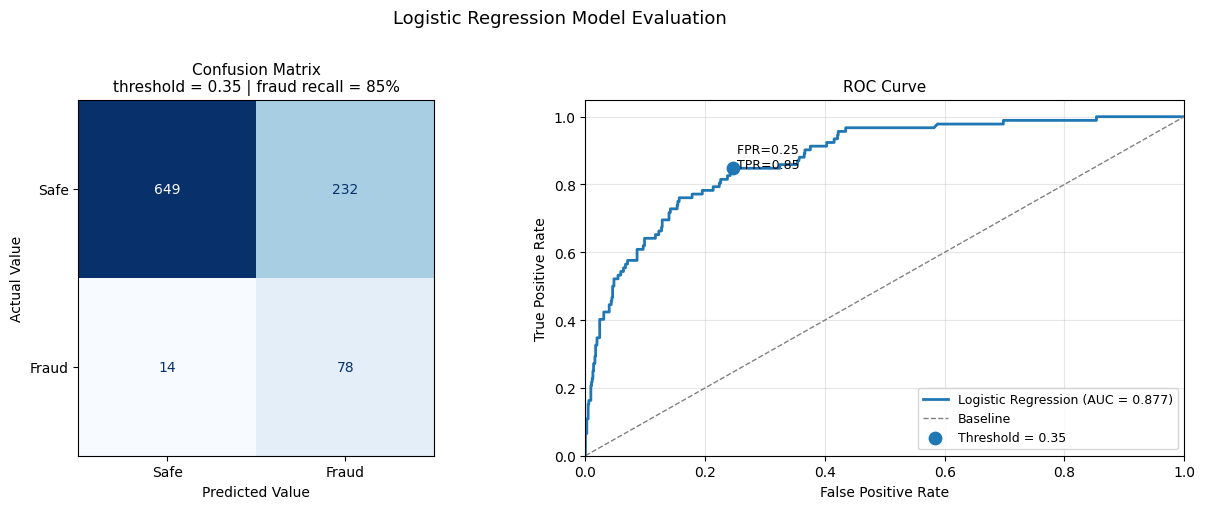

In [10]:
# =========================================================
# PHASE 2: SUBSETTING AND RETRAINING
# ON THE TOP 13
# =========================================================

core_features = [
    'institutional_friction',
    'credit_excluded',
    'expenditure_shock_capacity_yes_selling_assets',
    'edu_level_grouped_Middle School',
    'private_pension_asset',
    'qk6_clean',
    'saving_level_sophistication',
    'digital_onboarding_score',
    'advanced_fintech_intensity',
    'financial_planning_score',
    'household_size',
    'digital_skills_score',
    'saving_protection_score'
]

X_train_smote_13 = X_train_smote[core_features]
X_train_13 = X_train[core_features]
X_test_13 = X_test[core_features]

# =========================================================
# MODEL A: LOGISTIC REGRESSION
# =========================================================

# Sklearn
# (Predictions + ROC)
log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight='balanced'
)

log_reg.fit(
    X_train_13,
    y_train
)

# Statsmodels
# (Statistical inference)
X_train_sm = sm.add_constant(
    X_train_13
)

try:

    result = sm.Logit(
        y_train,
        X_train_sm
    ).fit(disp=False)

    infer_df = (
        pd.DataFrame({
            'Feature': result.params.index,
            'Coefficient': result.params.values,
            'Odds_Ratio': np.exp(result.params.values),
            'P_Value': result.pvalues.values
        })
        .query("Feature != 'const'")
        .assign(
            **{
                'Significant (p<0.05)':
                lambda d: d['P_Value'] < 0.05
            }
        )
        .sort_values(
            'Odds_Ratio',
            ascending=False
        )
    )

    print(
        "\n--- STATISTICAL INFERENCE: "
        "ODDS RATIO AND P-VALUE ---"
    )

    print(
        "Rule: Consider ONLY variables "
        "with Significant = True."
    )

    print(
        infer_df.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )

except Exception as e:

    print(
        f"\nStatsmodels did not converge "
        f"({e}) — sklearn odds ratio fallback"
    )

    infer_df = (
        pd.DataFrame({
            'Feature': core_features,
            'Odds_Ratio': np.exp(
                log_reg.coef_[0]
            )
        })
        .sort_values(
            'Odds_Ratio',
            ascending=False
        )
    )

    print(
        infer_df.to_string(
            index=False
        )
    )

# =========================================================
# ROC + CONFUSION MATRIX
# Unified two-panel figure
# =========================================================

from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

y_prob_log = log_reg.predict_proba(
    X_test_13
)[:, 1]

# Threshold selection
precisions, recalls, thresh_pr = (
    precision_recall_curve(
        y_test,
        y_prob_log
    )
)

THRESHOLD = 0.35

y_pred_log = (
    y_prob_log >= THRESHOLD
).astype(int)

print(
    f"\n--- LOGISTIC REGRESSION "
    f"PERFORMANCE "
    f"(threshold = {THRESHOLD:.3f}) ---"
)

print(
    classification_report(
        y_test,
        y_pred_log,
        target_names=[
            'Safe',
            'Fraud'
        ]
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

fig.suptitle(
    "Logistic Regression "
    "Model Evaluation",
    fontsize=13,
    y=1.01
)

# ----------------------------
# PANEL 1:
# Confusion Matrix
# ----------------------------

cm = confusion_matrix(
    y_test,
    y_pred_log
)

tn, fp, fn, tp = cm.ravel()

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Safe',
        'Fraud'
    ]
).plot(
    ax=axes[0],
    colorbar=False,
    cmap='Blues'
)

axes[0].set_title(
    f"Confusion Matrix\n"
    f"threshold = {THRESHOLD:.2f} | "
    f"fraud recall = {tp/(tp+fn):.0%}",
    fontsize=11
)

axes[0].set_xlabel(
    "Predicted Value"
)

axes[0].set_ylabel(
    "Actual Value"
)

# ----------------------------
# PANEL 2:
# ROC Curve
# ----------------------------

fpr, tpr, roc_thresh = roc_curve(
    y_test,
    y_prob_log
)

roc_auc_log = auc(
    fpr,
    tpr
)

axes[1].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Logistic Regression '
          f'(AUC = {roc_auc_log:.3f})'
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color='grey',
    label='Baseline'
)

thresh_idx = np.argmin(
    np.abs(
        roc_thresh - THRESHOLD
    )
)

axes[1].scatter(
    fpr[thresh_idx],
    tpr[thresh_idx],
    zorder=5,
    s=80,
    label=f'Threshold = {THRESHOLD:.2f}'
)

axes[1].annotate(
    f" FPR={fpr[thresh_idx]:.2f}\n"
    f" TPR={tpr[thresh_idx]:.2f}",
    xy=(
        fpr[thresh_idx],
        tpr[thresh_idx]
    ),
    fontsize=9
)

axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

axes[1].set_xlabel(
    "False Positive Rate"
)

axes[1].set_ylabel(
    "True Positive Rate"
)

axes[1].set_title(
    "ROC Curve",
    fontsize=11
)

axes[1].legend(
    loc="lower right",
    fontsize=9
)

axes[1].grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Grid Search for Random Forest and Decision Tree 

In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV

# 1. Prepare the raw training set (BEFORE SMOTE),
# filtered to the selected 15 core features.
# We assume X_train, y_train, X_test, and core_features already exist in the environment.
X_train_13 = X_train[core_features]
X_test_13 = X_test[core_features]

# ==========================================
# GRID SEARCH FOR DECISION TREE (Transparency)
# ==========================================

# Build pipeline: SMOTE is applied dynamically within each CV fold
dt_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# Define hyperparameter grid
# Keep max_depth between 3 and 5 to avoid overly large,
# non-interpretable trees for presentation purposes
param_grid_dt = {
    'dt__max_depth': [3, 5, 7],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 5, 10],
    'dt__criterion': ['gini', 'entropy']
}

print("Starting Grid Search for Decision Tree...")

# scoring='recall' because we want to maximize fraud detection
grid_dt = GridSearchCV(
    dt_pipe,
    param_grid_dt,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_dt.fit(X_train_13, y_train)

print("\n--- BEST DECISION TREE PARAMETERS ---")
print(grid_dt.best_params_)

print(
    f"Best Recall (Cross-Validation): "
    f"{grid_dt.best_score_:.3f}"
)


# ==========================================
# GRID SEARCH FOR RANDOM FOREST (Pure Performance)
# ==========================================

rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Wider hyperparameter grid for Random Forest
# since it is not constrained to visual interpretability
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [4, 6, 8, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2']
}

print(
    "\nStarting Grid Search for Random Forest "
    "(this may take a few minutes)..."
)

grid_rf = GridSearchCV(
    rf_pipe,
    param_grid_rf,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_rf.fit(X_train_13, y_train)

print("\n--- BEST RANDOM FOREST PARAMETERS ---")
print(grid_rf.best_params_)

print(
    f"Best Recall (Cross-Validation): "
    f"{grid_rf.best_score_:.3f}"
)


# ==========================================
# FINAL MODEL EVALUATION (ON TEST SET)
# ==========================================

# Extract best model from grid search
best_rf = grid_rf.best_estimator_

# Evaluate on untouched test set
y_pred_best_rf = best_rf.predict(X_test_13)

print("\n" + "=" * 50)
print("BEST RANDOM FOREST PERFORMANCE ON TEST SET")
print("=" * 50)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

Starting Grid Search for Decision Tree...

--- BEST DECISION TREE PARAMETERS ---
{'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Best Recall (Cross-Validation): 0.677

Starting Grid Search for Random Forest (this may take a few minutes)...

--- BEST RANDOM FOREST PARAMETERS ---
{'rf__max_depth': 4, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Best Recall (Cross-Validation): 0.697

BEST RANDOM FOREST PERFORMANCE ON TEST SET

Confusion Matrix:
[[784  97]
 [ 33  59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       881
           1       0.38      0.64      0.48        92

    accuracy                           0.87       973
   macro avg       0.67      0.77      0.70       973
weighted avg       0.90      0.87      0.88       973



### Addestramento Rndom forest con Grid Search


--- RANDOM FOREST PERFORMANCE (threshold = 0.349) ---
              precision    recall  f1-score   support

        Safe       0.98      0.83      0.90       881
       Fraud       0.33      0.82      0.47        92

    accuracy                           0.83       973
   macro avg       0.65      0.82      0.68       973
weighted avg       0.92      0.83      0.86       973



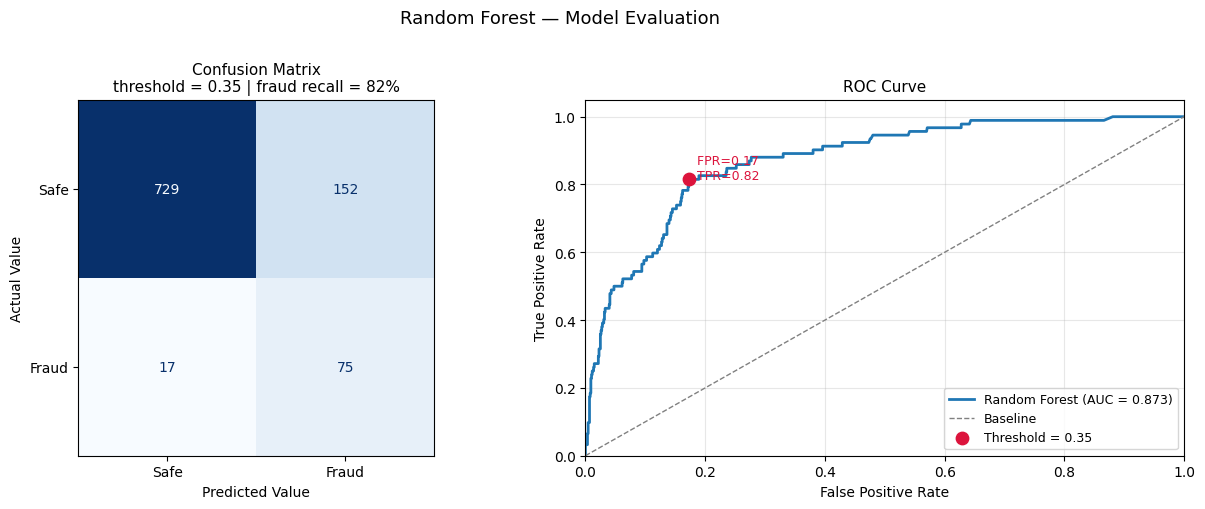

In [12]:
# Random Forest with best hyperparameters found
rf_best_model = RandomForestClassifier(
    n_estimators=grid_rf.best_params_['rf__n_estimators'],
    max_depth=grid_rf.best_params_['rf__max_depth'],
    min_samples_split=grid_rf.best_params_['rf__min_samples_split'],
    max_features=grid_rf.best_params_['rf__max_features'],
    random_state=42
)

rf_best_model.fit(X_train_smote_13, y_train_smote)
y_pred_best_rf = rf_best_model.predict(X_test_13)

# ============================
# CONFUSION MATRIX + ROC — RANDOM FOREST (optimized threshold)
# ============================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)

import matplotlib.pyplot as plt
import numpy as np

# --- raw predicted probabilities ---
y_prob_rf = rf_best_model.predict_proba(X_test_13)[:, 1]

# --- optimal F2 threshold (recall weighted higher than precision) ---
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

f2_scores = [
    (5 * p * r / (4 * p + r)) if (4 * p + r) > 0 else 0
    for p, r in zip(precisions[:-1], recalls[:-1])
]

best_thresh = thresholds[np.argmax(f2_scores)]

# --- optional manual override of threshold ---
THRESHOLD = best_thresh   # or e.g. 0.30 / 0.35

y_pred_rf = (y_prob_rf >= THRESHOLD).astype(int)

print(
    f"\n--- RANDOM FOREST PERFORMANCE "
    f"(threshold = {THRESHOLD:.3f}) ---"
)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['Safe', 'Fraud']
    )
)

# ── 2-panel figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Random Forest — Model Evaluation", fontsize=13, y=1.01)

# ── Panel 1: Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()
recall_fraud = tp / (tp + fn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Safe', 'Fraud']
)

disp.plot(
    ax=axes[0],
    colorbar=False,
    cmap='Blues'
)

axes[0].set_title(
    f"Confusion Matrix\n"
    f"threshold = {THRESHOLD:.2f} | fraud recall = {recall_fraud:.0%}",
    fontsize=11
)

axes[0].set_xlabel("Predicted Value")
axes[0].set_ylabel("Actual Value")

# ── Panel 2: ROC + selected threshold point ─────────────────────────────────
fpr_rf, tpr_rf, roc_thresholds = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

axes[1].plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f'Random Forest (AUC = {roc_auc_rf:.3f})'
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color='grey',
    label='Baseline'
)

# point corresponding to chosen threshold on ROC curve
thresh_idx = np.argmin(np.abs(roc_thresholds - THRESHOLD))

axes[1].scatter(
    fpr_rf[thresh_idx],
    tpr_rf[thresh_idx],
    color='crimson',
    zorder=5,
    s=80,
    label=f'Threshold = {THRESHOLD:.2f}'
)

axes[1].annotate(
    f"  FPR={fpr_rf[thresh_idx]:.2f}\n"
    f"  TPR={tpr_rf[thresh_idx]:.2f}",
    xy=(fpr_rf[thresh_idx], tpr_rf[thresh_idx]),
    fontsize=9,
    color='crimson'
)

axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=11)

axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Addestramento Decision Tree con Grid Search


--- DECISION TREE PERFORMANCE (threshold = 0.350) ---
              precision    recall  f1-score   support

        Safe       0.96      0.90      0.93       881
       Fraud       0.39      0.60      0.47        92

    accuracy                           0.87       973
   macro avg       0.67      0.75      0.70       973
weighted avg       0.90      0.87      0.88       973



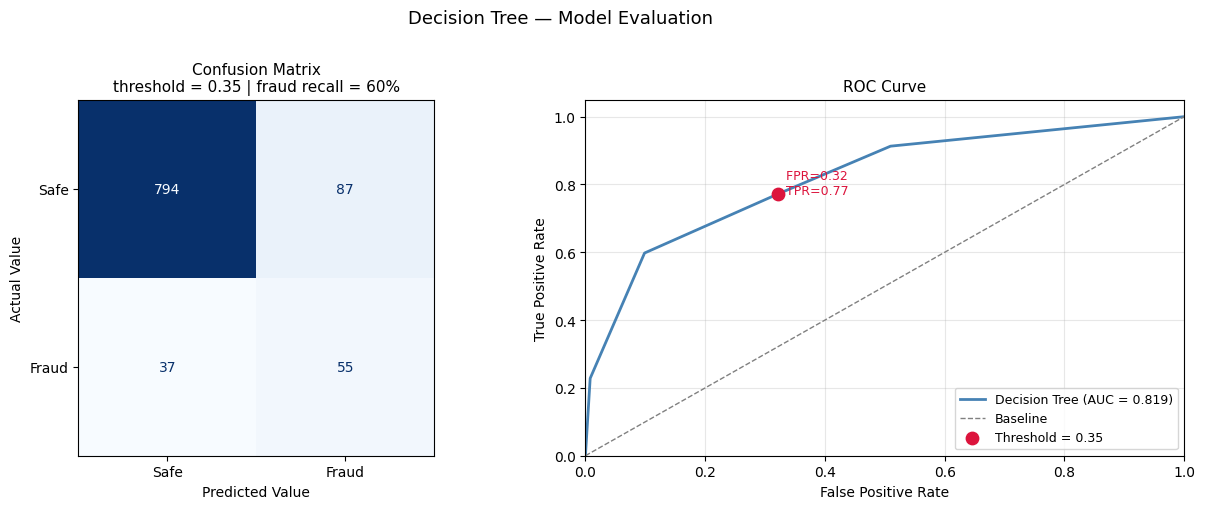

In [13]:
# {'dt__criterion': 'entropy', 'dt__max_depth': 3,
#  'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}

dt_best_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced"
)

dt_best_model.fit(X_train_smote_13, y_train_smote)
y_pred_best_dt = dt_best_model.predict(X_test_13)

# --- raw predicted probabilities ---
y_prob_dt = dt_best_model.predict_proba(X_test_13)[:, 1]

# --- optimal F2 threshold ---
# NOTE: With max_depth=3, the decision tree produces
# stepwise probabilities (few distinct values),
# so the PR curve is less smooth than RF/LogReg —
# expected behavior, not a bug.
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_dt)

f2_scores = [
    (5 * p * r / (4 * p + r)) if (4 * p + r) > 0 else 0
    for p, r in zip(precisions[:-1], recalls[:-1])
]

THRESHOLD = 0.35   # or manually set, e.g. 0.35

y_pred_dt = (y_prob_dt >= THRESHOLD).astype(int)

print(
    f"\n--- DECISION TREE PERFORMANCE "
    f"(threshold = {THRESHOLD:.3f}) ---"
)

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=['Safe', 'Fraud']
    )
)

# ── 2-panel figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Decision Tree — Model Evaluation", fontsize=13, y=1.01)

# ── Panel 1: Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_dt)
tn, fp, fn, tp = cm.ravel()
recall_fraud = tp / (tp + fn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Safe', 'Fraud']
)

disp.plot(
    ax=axes[0],
    colorbar=False,
    cmap='Blues'
)

axes[0].set_title(
    f"Confusion Matrix\n"
    f"threshold = {THRESHOLD:.2f} | fraud recall = {recall_fraud:.0%}",
    fontsize=11
)

axes[0].set_xlabel("Predicted Value")
axes[0].set_ylabel("Actual Value")

# ── Panel 2: ROC + threshold point ───────────────────────────────────────────
fpr_dt, tpr_dt, roc_thresholds = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

axes[1].plot(
    fpr_dt,
    tpr_dt,
    linewidth=2,
    color='steelblue',
    label=f'Decision Tree (AUC = {roc_auc_dt:.3f})'
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color='grey',
    label='Baseline'
)

# threshold point on ROC curve
thresh_idx = np.argmin(np.abs(roc_thresholds - THRESHOLD))

axes[1].scatter(
    fpr_dt[thresh_idx],
    tpr_dt[thresh_idx],
    color='crimson',
    zorder=5,
    s=80,
    label=f'Threshold = {THRESHOLD:.2f}'
)

axes[1].annotate(
    f"  FPR={fpr_dt[thresh_idx]:.2f}\n"
    f"  TPR={tpr_dt[thresh_idx]:.2f}",
    xy=(fpr_dt[thresh_idx], tpr_dt[thresh_idx]),
    fontsize=9,
    color='crimson'
)

axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=11)

axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### SHAP su Decisoon Tree post Grid Search 


Generazione SHAP Values...


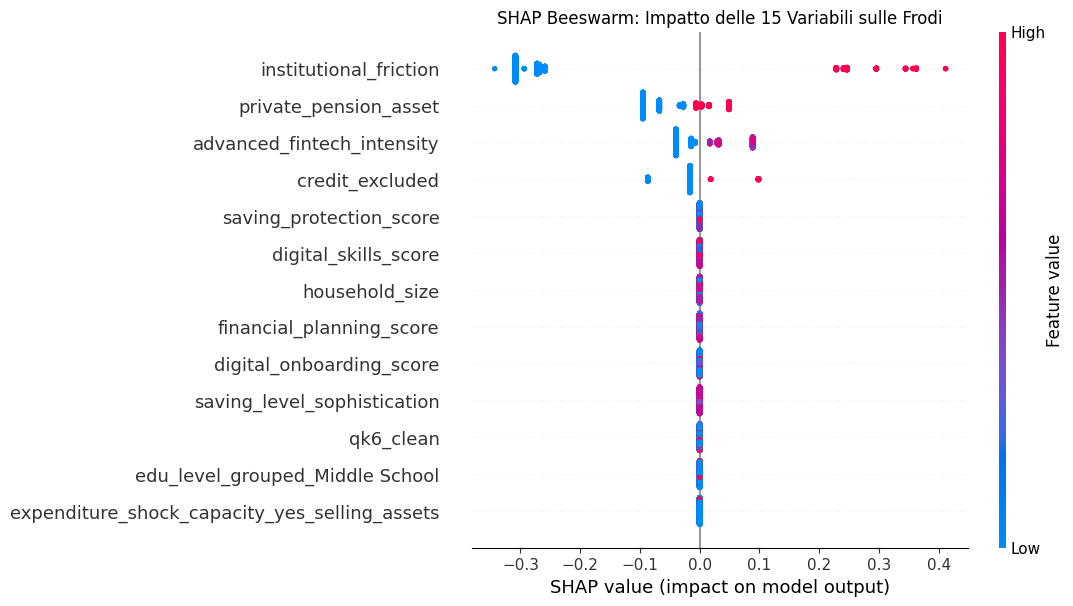

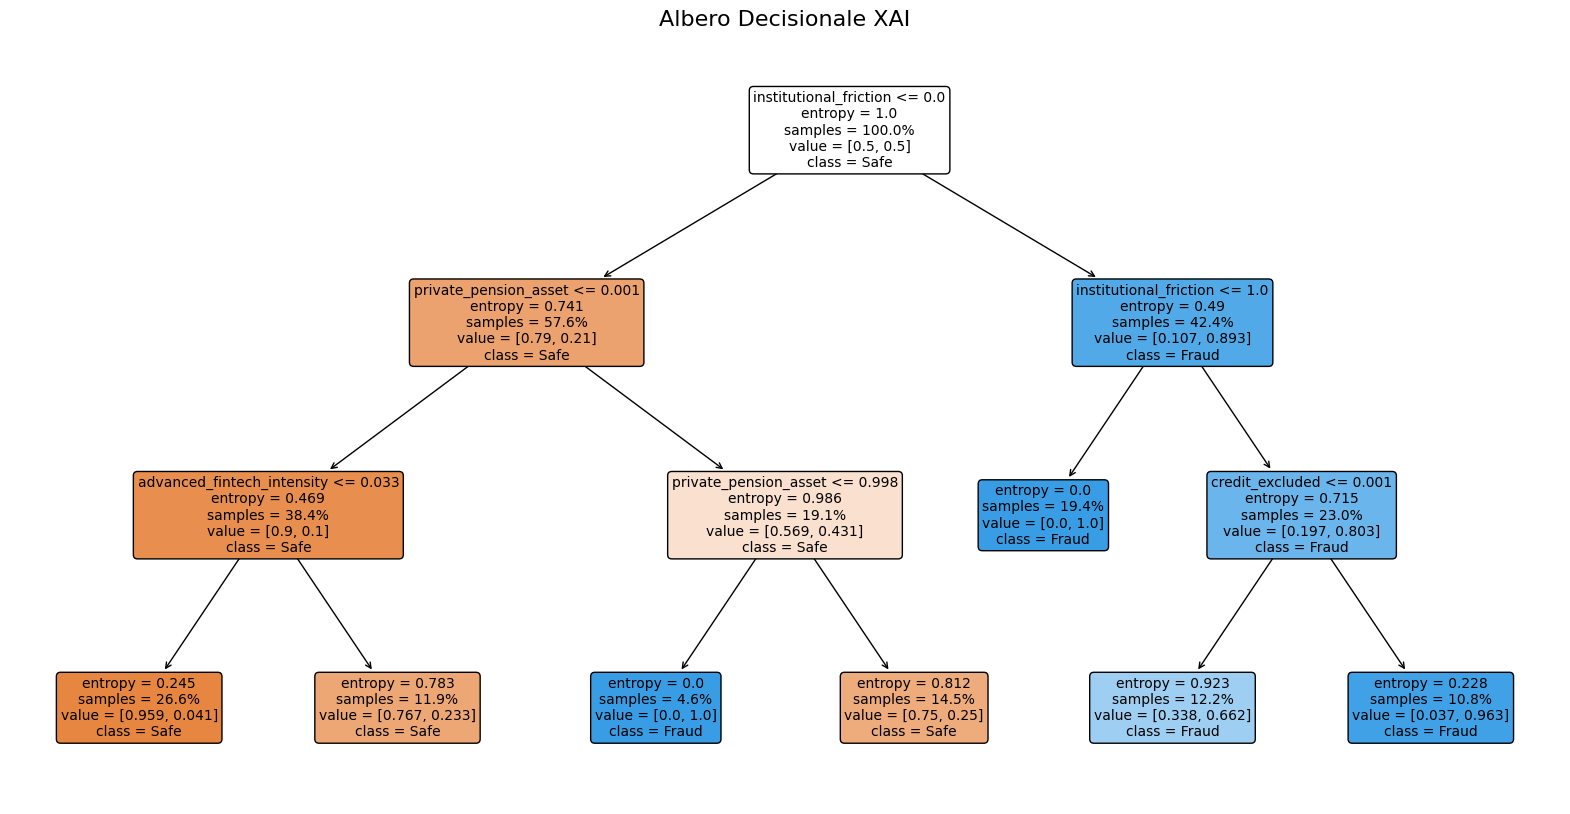

In [14]:
# XAI: SHAP Beeswarm Plot (Sull'Albero e sul Test Set)
print("\nGenerazione SHAP Values...")
explainer = shap.TreeExplainer(dt_best_model)
shap_values = explainer(X_test_13)

plt.figure()
plt.title("SHAP Beeswarm: Impatto delle 15 Variabili sulle Frodi")
try:
    shap.plots.beeswarm(shap_values[:, :, 1], max_display=15)
except:
    shap.plots.beeswarm(shap_values, max_display=15)

# Visualizzazione Albero
plt.figure(figsize=(20, 10))
plot_tree(dt_best_model, feature_names=core_features, class_names=['Safe', 'Fraud'], 
          filled=True, rounded=True, proportion=True, fontsize=10)
plt.title("Albero Decisionale XAI", fontsize=16)
plt.show()

### Grid Search SVM

In [15]:
# =========================================================
# GRIDSEARCH — SVM COST-SENSITIVE (SMOTE)
# =========================================================
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid_svm_smote = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'sigmoid'],
}

grid_svm_smote = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid_svm_smote,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

grid_svm_smote.fit(X_train_smote_13, y_train_smote)  # dati SMOTE

print("\nMigliori parametri SVM (SMOTE):")
print(grid_svm_smote.best_params_)
print(f"Miglior F1 in CV: {grid_svm_smote.best_score_:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Migliori parametri SVM (SMOTE):
{'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Miglior F1 in CV: 0.9522


### Addestramento di SVM con Grid Search e Treshold 0.35


--- SVM SMOTE (threshold = 0.35) ---
              precision    recall  f1-score   support

        Safe       0.94      0.91      0.92       881
       Fraud       0.34      0.45      0.38        92

    accuracy                           0.87       973
   macro avg       0.64      0.68      0.65       973
weighted avg       0.88      0.87      0.87       973



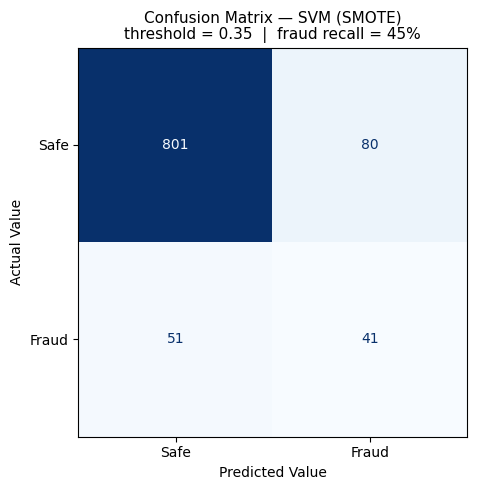

In [16]:
# =========================================================
# SVM — SMOTE (parametri da GridSearch)
# =========================================================
THRESHOLD = 0.35

svm_smote = SVC(
    C=         grid_svm_smote.best_params_['C'],
    gamma=     grid_svm_smote.best_params_['gamma'],
    kernel=    grid_svm_smote.best_params_['kernel'],
    probability=True,
    random_state=42
)

svm_smote.fit(X_train_smote_13, y_train_smote)

y_prob_svm_smote = svm_smote.predict_proba(X_test_13)[:, 1]
y_pred_svm_smote = (y_prob_svm_smote >= THRESHOLD).astype(int)

print(f"\n--- SVM SMOTE (threshold = {THRESHOLD}) ---")
print(classification_report(y_test, y_pred_svm_smote,
                             target_names=['Safe', 'Fraud']))

# ── Confusion Matrix ──────────────────────────────────────
cm_svm_smote = confusion_matrix(y_test, y_pred_svm_smote)
tn, fp, fn, tp = cm_svm_smote.ravel()
recall_fraud   = tp / (tp + fn)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_svm_smote,
                       display_labels=['Safe', 'Fraud']).plot(
    ax=ax, colorbar=False, cmap='Blues')

ax.set_title(
    f"Confusion Matrix — SVM (SMOTE)\n"
    f"threshold = {THRESHOLD:.2f}  |  fraud recall = {recall_fraud:.0%}",
    fontsize=11
)
ax.set_xlabel("Predicted Value")
ax.set_ylabel("Actual Value")
plt.tight_layout()
plt.show()

## Confronto Modelli

piccola modifica al codice di Trio, non erano specificate COST_FN e COST_FP, si stampano comuqnue i risultati dei classificatori fatti con SMOTE, ma non si riusciva a calcoalre il costo totale di missclassificazione
Il codice runnava solo dopo aver runnato la cella successiva quindi è stato aggiunto ( COST_FN = 5    # cost of missed fraud
COST_FP = 1    # cost of false alarm
) al codice 

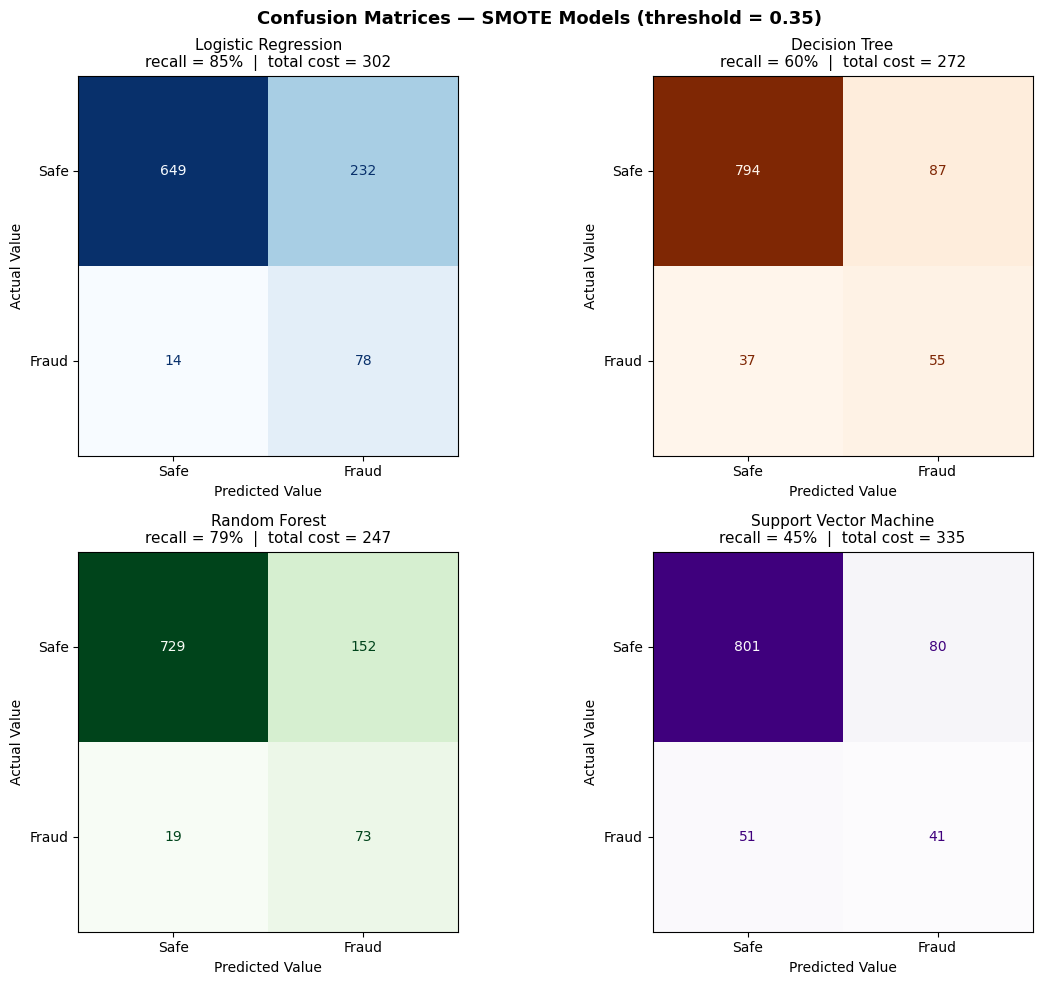

In [17]:
# =========================================================
# CONFUSION MATRICES — SMOTE MODELS (2x2 grid)
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Confusion Matrices — SMOTE Models (threshold = 0.35)",
             fontsize=13, fontweight='bold')

smote_model_probs = {
    'LogReg': (log_reg,       log_reg.predict_proba(X_test_13)[:, 1]),
    'DT':     (dt_best_model, dt_best_model.predict_proba(X_test_13)[:, 1]),
    'RF':     (rf_best_model, rf_best_model.predict_proba(X_test_13)[:, 1]),
    'SVM':    (svm_smote,     svm_smote.predict_proba(X_test_13)[:, 1]),
}

titles = {
    'LogReg': 'Logistic Regression',
    'DT':     'Decision Tree',
    'RF':     'Random Forest',
    'SVM':    'Support Vector Machine',
}

cmaps = {
    'LogReg': 'Blues',
    'DT':     'Oranges',
    'RF':     'Greens',
    'SVM':    'Purples',
}
COST_FN = 5    # cost of missed fraud
COST_FP = 1    # cost of false alarm

for ax, (name, (model, y_prob)) in zip(axes.flatten(),
                                        smote_model_probs.items()):
    y_pred         = (y_prob >= THRESHOLD).astype(int)
    cm             = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall_fraud   = tp / (tp + fn)
    total_cost     = fn * COST_FN + fp * COST_FP

    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['Safe', 'Fraud']).plot(
        ax=ax, colorbar=False, cmap=cmaps[name])

    ax.set_title(
        f"{titles[name]}\n"
        f"recall = {recall_fraud:.0%}  |  total cost = {total_cost:.0f}",
        fontsize=11
    )
    ax.set_xlabel("Predicted Value")
    ax.set_ylabel("Actual Value")

plt.tight_layout()
plt.show()

# Profilazione dei Falsi Negativi

TP: 78 | FN: 14 | FP: 232 | TN: 649
Fraud recall: 85%

Sizes: TP=78 | FN=14

--- MEAN COMPARISON: TP vs FN (numerical variables) ---
                    Feature  Mean_TP  Mean_FN  Delta  p_value Sig
 advanced_fintech_intensity    2.449    0.929 -1.520    0.002 ***
   digital_onboarding_score    1.590    0.429 -1.161    0.006 ***
   financial_planning_score    4.282    2.929 -1.353    0.016   *
             household_size    2.974    3.714  0.740    0.069   —
saving_level_sophistication    2.231    1.857 -0.374    0.076   —
                  qk6_clean    0.590    0.357 -0.233    0.110   —
    saving_protection_score    0.436    0.714  0.278    0.411   —
       digital_skills_score    2.813    2.704 -0.109    0.987   —

--- FREQUENCY COMPARISON: TP vs FN (categorical variables) ---
                                      Feature  Pct_TP  Pct_FN  Delta  p_value Sig
                       institutional_friction   0.705   0.000 -0.705    0.000 ***
                        private_pension_asset

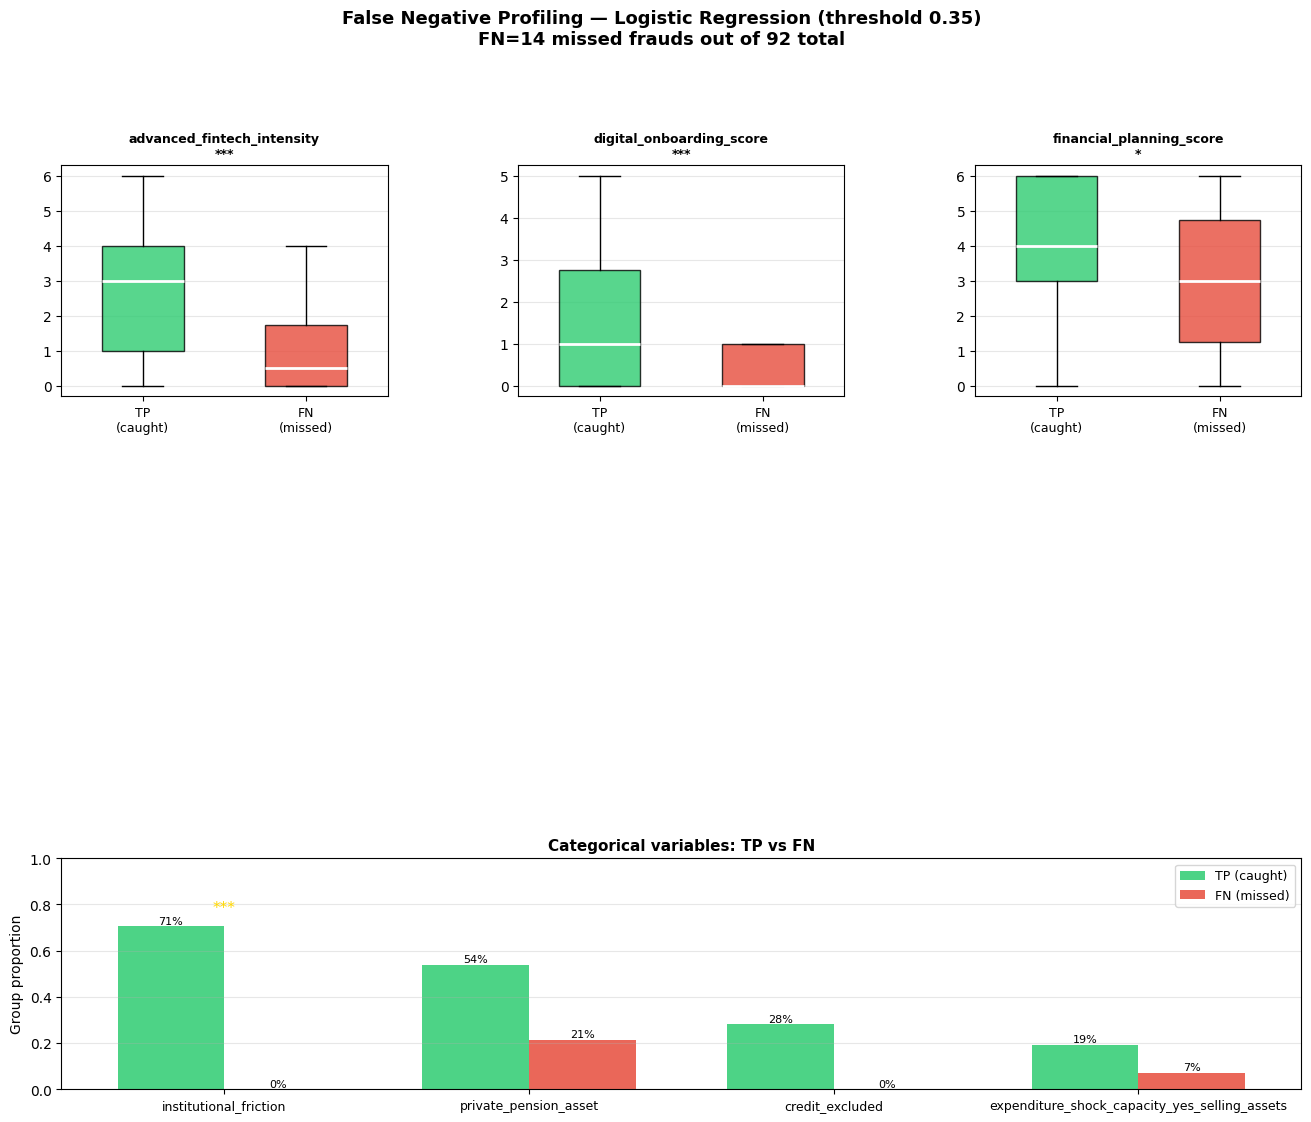


SUMMARY — PROFILE OF THE INVISIBLE FRAUD CASES

Numerical variables differentiating FN vs TP:
                   Feature  Mean_TP  Mean_FN  Delta Sig
advanced_fintech_intensity    2.449    0.929 -1.520 ***
  digital_onboarding_score    1.590    0.429 -1.161 ***
  financial_planning_score    4.282    2.929 -1.353   *

Categorical variables differentiating FN vs TP:
               Feature  Pct_TP  Pct_FN  Delta Sig
institutional_friction   0.705   0.000 -0.705 ***

Model-assigned probability:
  TP: 0.776 → FN: 0.245

Interpretation: false negatives are cases the model considers
'almost safe' — low predicted probability but actual frauds.
Features with negative Delta indicate cases where FN
resemble non-fraud observations, confusing the model.


In [20]:
# =========================================================
# FALSE NEGATIVE PROFILING — LOGISTIC REGRESSION (threshold 0.35)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings

warnings.filterwarnings('ignore')

THRESHOLD = 0.35

# ── 1. RECONSTRUCT CLASSIFICATION LABELS ─────────────────────────────────────
y_prob_log = log_reg.predict_proba(X_test_13)[:, 1]
y_pred_035 = (y_prob_log >= THRESHOLD).astype(int)
y_test_arr = np.array(y_test)

# Masks for confusion matrix quadrants
mask_TP = (y_test_arr == 1) & (y_pred_035 == 1)   # fraud correctly detected ✓
mask_FN = (y_test_arr == 1) & (y_pred_035 == 0)   # missed fraud ✗
mask_FP = (y_test_arr == 0) & (y_pred_035 == 1)   # false alarm
mask_TN = (y_test_arr == 0) & (y_pred_035 == 0)   # correct safe

print(
    f"TP: {mask_TP.sum()} | FN: {mask_FN.sum()} | "
    f"FP: {mask_FP.sum()} | TN: {mask_TN.sum()}"
)

print(
    f"Fraud recall: "
    f"{mask_TP.sum() / (mask_TP.sum() + mask_FN.sum()):.0%}"
)

# ── 2. WORKING DATAFRAME (test set + labels) ─────────────────────────────────
df_test = X_test_13.copy().reset_index(drop=True)
df_test['y_true'] = y_test_arr
df_test['y_pred'] = y_pred_035
df_test['prob_fraud'] = y_prob_log
df_test['quadrant'] = 'TN'

df_test.loc[mask_TP, 'quadrant'] = 'TP'
df_test.loc[mask_FN, 'quadrant'] = 'FN'
df_test.loc[mask_FP, 'quadrant'] = 'FP'

# Subsets TP and FN (focus groups)
df_TP = df_test[df_test['quadrant'] == 'TP']
df_FN = df_test[df_test['quadrant'] == 'FN']

print(f"\nSizes: TP={len(df_TP)} | FN={len(df_FN)}")

# ── 3. NUMERICAL COMPARISON TP vs FN ────────────────────────────────────────
numeric_features = [
    'digital_onboarding_score',
    'advanced_fintech_intensity',
    'financial_planning_score',
    'digital_skills_score',
    'saving_level_sophistication',
    'saving_protection_score',
    'household_size',
    'qk6_clean'
]

print("\n--- MEAN COMPARISON: TP vs FN (numerical variables) ---")

rows = []

for feat in numeric_features:
    tp_vals = df_TP[feat].dropna()
    fn_vals = df_FN[feat].dropna()

    stat, p = mannwhitneyu(tp_vals, fn_vals, alternative='two-sided')

    rows.append({
        'Feature': feat,
        'Mean_TP': tp_vals.mean(),
        'Mean_FN': fn_vals.mean(),
        'Delta': fn_vals.mean() - tp_vals.mean(),
        'p_value': p,
        'Sig': '***' if p < 0.01 else ('*' if p < 0.05 else '—')
    })

num_df = pd.DataFrame(rows).sort_values('p_value')

print(
    num_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

# ── 4. CATEGORICAL COMPARISON TP vs FN ──────────────────────────────────────
cat_features = [
    'institutional_friction',
    'credit_excluded',
    'private_pension_asset',
    'expenditure_shock_capacity_yes_selling_assets'
]

print("\n--- FREQUENCY COMPARISON: TP vs FN (categorical variables) ---")

cat_rows = []

for feat in cat_features:
    pct_tp = df_TP[feat].mean()
    pct_fn = df_FN[feat].mean()

    ct = pd.crosstab(
        df_test.loc[df_test['quadrant'].isin(['TP', 'FN']), 'quadrant'],
        df_test.loc[df_test['quadrant'].isin(['TP', 'FN']), feat]
    )

    if ct.shape == (2, 2):
        _, p, _, _ = chi2_contingency(ct)
    else:
        p = np.nan

    cat_rows.append({
        'Feature': feat,
        'Pct_TP': pct_tp,
        'Pct_FN': pct_fn,
        'Delta': pct_fn - pct_tp,
        'p_value': p,
        'Sig': '***' if p < 0.01 else ('*' if p < 0.05 else '—')
    })

cat_df = pd.DataFrame(cat_rows).sort_values('p_value')

print(
    cat_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

# ── 5. MODEL ASSIGNED PROBABILITIES ─────────────────────────────────────────
print("\n--- MODEL ASSIGNED PROBABILITIES ---")

print(
    f"TP (detected frauds): mean prob = {df_TP['prob_fraud'].mean():.3f} "
    f"| min = {df_TP['prob_fraud'].min():.3f} "
    f"| max = {df_TP['prob_fraud'].max():.3f}"
)

print(
    f"FN (missed frauds): mean prob = {df_FN['prob_fraud'].mean():.3f} "
    f"| min = {df_FN['prob_fraud'].min():.3f} "
    f"| max = {df_FN['prob_fraud'].max():.3f}"
)

# ── 6. VISUALIZATION ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

colors = {'TP': '#2ecc71', 'FN': '#e74c3c'}

# Boxplots for top numerical features
top_num = num_df[num_df['Sig'] != '—']['Feature'].tolist()[:6]
if not top_num:
    top_num = num_df['Feature'].tolist()[:6]

for i, feat in enumerate(top_num):
    row, col = divmod(i, 3)
    ax = fig.add_subplot(gs[row, col])

    data = [df_TP[feat].dropna(), df_FN[feat].dropna()]

    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='white', linewidth=2)
    )

    for patch, c in zip(bp['boxes'], [colors['TP'], colors['FN']]):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['TP\n(caught)', 'FN\n(missed)'], fontsize=9)

    sig_tag = num_df.loc[num_df['Feature'] == feat, 'Sig'].values[0]

    ax.set_title(
        f"{feat}\n{sig_tag}",
        fontsize=9,
        fontweight='bold'
    )

    ax.grid(axis='y', alpha=0.3)

# Barplot categorical variables
ax_bar = fig.add_subplot(gs[2, :])

x = np.arange(len(cat_features))
width = 0.35

bars_tp = ax_bar.bar(
    x - width/2,
    cat_df['Pct_TP'],
    width,
    label='TP (caught)',
    color=colors['TP'],
    alpha=0.85
)

bars_fn = ax_bar.bar(
    x + width/2,
    cat_df['Pct_FN'],
    width,
    label='FN (missed)',
    color=colors['FN'],
    alpha=0.85
)

# Percentage labels
for bar in bars_tp:
    ax_bar.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.0%}",
        ha='center',
        fontsize=8
    )

for bar in bars_fn:
    ax_bar.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.0%}",
        ha='center',
        fontsize=8
    )

# Significance markers
for j, row in cat_df.reset_index(drop=True).iterrows():
    if row['Sig'] != '—':
        y_max = max(row['Pct_TP'], row['Pct_FN']) + 0.06
        ax_bar.text(j, y_max, row['Sig'],
                    ha='center',
                    fontsize=11,
                    color='gold')

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(cat_df['Feature'].tolist(), fontsize=9)
ax_bar.set_ylabel("Group proportion")
ax_bar.set_title("Categorical variables: TP vs FN",
                 fontsize=11, fontweight='bold')
ax_bar.legend(fontsize=9)
ax_bar.set_ylim(0, 1)
ax_bar.grid(axis='y', alpha=0.3)

fig.suptitle(
    f"False Negative Profiling — Logistic Regression (threshold {THRESHOLD})\n"
    f"FN={mask_FN.sum()} missed frauds out of {(y_test_arr==1).sum()} total",
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.show()

# ── 7. NARRATIVE SUMMARY ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY — PROFILE OF THE INVISIBLE FRAUD CASES")
print("=" * 60)

sig_num = num_df[num_df['Sig'] != '—'][['Feature','Mean_TP','Mean_FN','Delta','Sig']]
sig_cat = cat_df[cat_df['Sig'] != '—'][['Feature','Pct_TP','Pct_FN','Delta','Sig']]

if not sig_num.empty:
    print("\nNumerical variables differentiating FN vs TP:")
    print(sig_num.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

if not sig_cat.empty:
    print("\nCategorical variables differentiating FN vs TP:")
    print(sig_cat.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\nModel-assigned probability:")
print(f"  TP: {df_TP['prob_fraud'].mean():.3f} → FN: {df_FN['prob_fraud'].mean():.3f}")

print("\nInterpretation: false negatives are cases the model considers")
print("'almost safe' — low predicted probability but actual frauds.")

print("Features with negative Delta indicate cases where FN")
print("resemble non-fraud observations, confusing the model.")

# Classificazione con COST-SENSITIVE ANALYSIS

In [18]:
# =========================================================
# COST-SENSITIVE LEARNING — Setup
# =========================================================

# Alternative to SMOTE: instead of rebalancing the dataset,
# we make the model explicitly aware of asymmetric error costs.
# More realistic for banking fraud detection.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings

warnings.filterwarnings('ignore')

# ── Cost matrix definition ───────────────────────────────
# Context: banking fraud detection for customer retention
#
#               Predicted Safe     Predicted Fraud
# Actual Safe        0                  1        ← FP: false alarm (customer friction)
# Actual Fraud       5                  0        ← FN: missed fraud (financial + reputational loss)
#
# FN:FP ratio = 5:1 (conservative, aligned with banking literature)

COST_FN = 5    # cost of missed fraud
COST_FP = 1    # cost of false alarm

# Equivalent class weights: class 1 (fraud) weight = COST_FN
cost_weights = {0: COST_FP, 1: COST_FN}

print("Cost matrix defined:")
print(f"  False Negative (missed fraud) → cost {COST_FN}")
print(f"  False Positive (false alarm) → cost {COST_FP}")
print(f"  FN:FP ratio = {COST_FN}:{COST_FP}")

print("\nNote: models are trained on ORIGINAL X_train")
print("(without SMOTE) — class imbalance is handled")
print("entirely through loss function weighting.")

Cost matrix defined:
  False Negative (missed fraud) → cost 5
  False Positive (false alarm) → cost 1
  FN:FP ratio = 5:1

Note: models are trained on ORIGINAL X_train
(without SMOTE) — class imbalance is handled
entirely through loss function weighting.


### Grid Searhc su Decision Tree

In [19]:
# =========================================================
# GRID SEARCH — COST-SENSITIVE DECISION TREE
# (to be placed BEFORE Cell 2 - Cost-Sensitive Training)
# =========================================================

# Note: separate grid from the SMOTE-based setup because the
# learning context is different — original imbalanced data
# with asymmetric cost weighting.
#
# Higher max_depth values are explored: without SMOTE,
# fraud signal is weaker and deeper trees may be required.

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold

param_grid_dt_cost = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
}

grid_dt_cost = GridSearchCV(
    estimator=DecisionTreeClassifier(
        class_weight=cost_weights,  # fixed — business decision, not tuned
        random_state=42
    ),
    param_grid=param_grid_dt_cost,
    scoring='f1',  # F1 score for fraud class, consistent with previous setup
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    n_jobs=-1,
    verbose=1
)

grid_dt_cost.fit(X_train_13, y_train)  # original training set, no SMOTE

print("\nBest cost-sensitive Decision Tree parameters:")
print(grid_dt_cost.best_params_)

print(f"Best CV F1 score: {grid_dt_cost.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best cost-sensitive Decision Tree parameters:
{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1 score: 0.5052


### Grid Search su Random Forest

In [20]:
# =========================================================
# GRID SEARCH — COST-SENSITIVE RANDOM FOREST
# (to be placed AFTER DT GridSearch, BEFORE Cell 2)
# =========================================================

param_grid_rf_cost = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

grid_rf_cost = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight=cost_weights,  # fixed — business decision
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf_cost,
    scoring='f1',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    n_jobs=-1,
    verbose=1
)

grid_rf_cost.fit(X_train_13, y_train)  # original training set, no SMOTE

print("\nBest cost-sensitive Random Forest parameters:")
print(grid_rf_cost.best_params_)

print(f"Best CV F1 score: {grid_rf_cost.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best cost-sensitive Random Forest parameters:
{'max_depth': 6, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 score: 0.5509


### Grid Search su SVM

In [21]:
# =========================================================
# GRIDSEARCH — SVM COST-SENSITIVE (COST MATRIX)
# =========================================================

param_grid_svm_cost = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'sigmoid'],
}

grid_svm_cost = GridSearchCV(
    estimator=SVC(
        class_weight={0: 1, 1: 5},   # cost matrix fissa — scelta di business
        probability=True,
        random_state=42
    ),
    param_grid=param_grid_svm_cost,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

grid_svm_cost.fit(X_train_13, y_train)   # dati ORIGINALI, senza SMOTE

print("\nMigliori parametri SVM (Cost Matrix):")
print(grid_svm_cost.best_params_)
print(f"Miglior F1 in CV: {grid_svm_cost.best_score_:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Migliori parametri SVM (Cost Matrix):
{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Miglior F1 in CV: 0.5319


### Addestramento Logistic Regression, Decision Tree and SVM 

In [22]:
# =========================================================
# COST-SENSITIVE TRAINING (no SMOTE, original data)
# =========================================================

THRESHOLD = 0.35  # same threshold used in previous models

# ── Cost-sensitive Logistic Regression ───────────────────
log_cost = LogisticRegression(
    class_weight=cost_weights,
    max_iter=2000,
    random_state=42
)
log_cost.fit(X_train_13, y_train)

# ── Cost-sensitive Decision Tree ─────────────────────────
dt_cost = DecisionTreeClassifier(
    criterion=         grid_dt_cost.best_params_['criterion'],
    max_depth=         grid_dt_cost.best_params_['max_depth'],
    min_samples_split= grid_dt_cost.best_params_['min_samples_split'],
    min_samples_leaf=  grid_dt_cost.best_params_['min_samples_leaf'],
    class_weight=cost_weights,
    random_state=42
)
dt_cost.fit(X_train_13, y_train)

# ── Cost-sensitive Random Forest ─────────────────────────
rf_cost = RandomForestClassifier(
    n_estimators=      grid_rf_cost.best_params_['n_estimators'],
    max_depth=         grid_rf_cost.best_params_['max_depth'],
    min_samples_split= grid_rf_cost.best_params_['min_samples_split'],
    max_features=      grid_rf_cost.best_params_['max_features'],
    class_weight=cost_weights,
    random_state=42,
    n_jobs=-1
)
rf_cost.fit(X_train_13, y_train)

# ── Cost-sensitive SVM ───────────────────────────────────
svm_cost = SVC(
    C=           grid_svm_cost.best_params_['C'],
    gamma=       grid_svm_cost.best_params_['gamma'],
    kernel=      grid_svm_cost.best_params_['kernel'],
    class_weight=cost_weights,
    probability= True,
    random_state=42
)
svm_cost.fit(X_train_13, y_train)

# ── Test set probabilities ───────────────────────────────
probs = {
    'LogReg': log_cost.predict_proba(X_test_13)[:, 1],
    'DT':     dt_cost.predict_proba(X_test_13)[:, 1],
    'RF':     rf_cost.predict_proba(X_test_13)[:, 1],
    'SVM':    svm_cost.predict_proba(X_test_13)[:, 1],
}

print("Training completed for all cost-sensitive models.")
print(f"Classification threshold: {THRESHOLD}")

Training completed for all cost-sensitive models.
Classification threshold: 0.35


### Prestazioni e Risultati 

In [23]:
# =========================================================
# EVALUATION: PERFORMANCE + TOTAL ERROR COST (+ SVM)
# =========================================================

def evaluate_cost(name, y_true, y_prob, threshold, cost_fn, cost_fp):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    total_cost = fn * cost_fn + fp * cost_fp

    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f2        = (5 * precision * recall / (4 * precision + recall)
                 if (4 * precision + recall) > 0 else 0)
    roc_auc   = auc(*roc_curve(y_true, y_prob)[:2])

    return {
        'Model':      name,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Recall':     recall,
        'Precision':  precision,
        'F2':         f2,
        'AUC':        roc_auc,
        'Cost_FN':    fn * cost_fn,
        'Cost_FP':    fp * cost_fp,
        'Total_Cost': total_cost,
    }

results_cost = pd.DataFrame([
    evaluate_cost('LogReg cost', y_test, probs['LogReg'],      THRESHOLD, COST_FN, COST_FP),
    evaluate_cost('DT cost',     y_test, probs['DT'],          THRESHOLD, COST_FN, COST_FP),
    evaluate_cost('RF cost',     y_test, probs['RF'],          THRESHOLD, COST_FN, COST_FP),
    evaluate_cost('SVM cost',    y_test, probs['SVM'],      THRESHOLD, COST_FN, COST_FP),
])

print("\n--- COST-SENSITIVE MODEL PERFORMANCE ---")
print(
    results_cost[
        ['Model','TP','FP','FN','TN',
         'Recall','Precision','F2','AUC']
    ].to_string(index=False, float_format=lambda x: f"{x:.3f}")
)

print("\n--- TOTAL ERROR COST ---")
print(
    results_cost[
        ['Model','FN','Cost_FN',
         'FP','Cost_FP','Total_Cost']
    ].to_string(index=False, float_format=lambda x: f"{x:.1f}")
)

print(f"\nCost interpretation:")
print(f"  Cost_FN = FN × {COST_FN}  (fraud + reputational damage)")
print(f"  Cost_FP = FP × {COST_FP}  (customer friction)")
print("  The model with the lowest Total_Cost is optimal for the bank.")


--- COST-SENSITIVE MODEL PERFORMANCE ---
      Model  TP  FP  FN  TN  Recall  Precision    F2   AUC
LogReg cost  64 120  28 761   0.696      0.348 0.580 0.877
    DT cost  61 134  31 747   0.663      0.313 0.542 0.785
    RF cost  64 105  28 776   0.696      0.379 0.596 0.882
   SVM cost  40  38  52 843   0.435      0.513 0.448 0.870

--- TOTAL ERROR COST ---
      Model  FN  Cost_FN  FP  Cost_FP  Total_Cost
LogReg cost  28      140 120      120         260
    DT cost  31      155 134      134         289
    RF cost  28      140 105      105         245
   SVM cost  52      260  38       38         298

Cost interpretation:
  Cost_FN = FN × 5  (fraud + reputational damage)
  Cost_FP = FP × 1  (customer friction)
  The model with the lowest Total_Cost is optimal for the bank.



--- SMOTE vs COST MATRIX: TOTAL COST COMPARISON ---
       Model    Approach  Recall   AUC  Cost_FN  Cost_FP  Total_Cost
LogReg SMOTE       SMOTE   0.848 0.877       70      232         302
    DT SMOTE       SMOTE   0.598 0.819      185       87         272
    RF SMOTE       SMOTE   0.793 0.873       95      152         247
   SVM SMOTE       SMOTE   0.446 0.733      255       80         335
 LogReg cost Cost Matrix   0.696 0.877      140      120         260
     DT cost Cost Matrix   0.663 0.785      155      134         289
     RF cost Cost Matrix   0.696 0.882      140      105         245
    SVM cost Cost Matrix   0.435 0.870      260       38         298


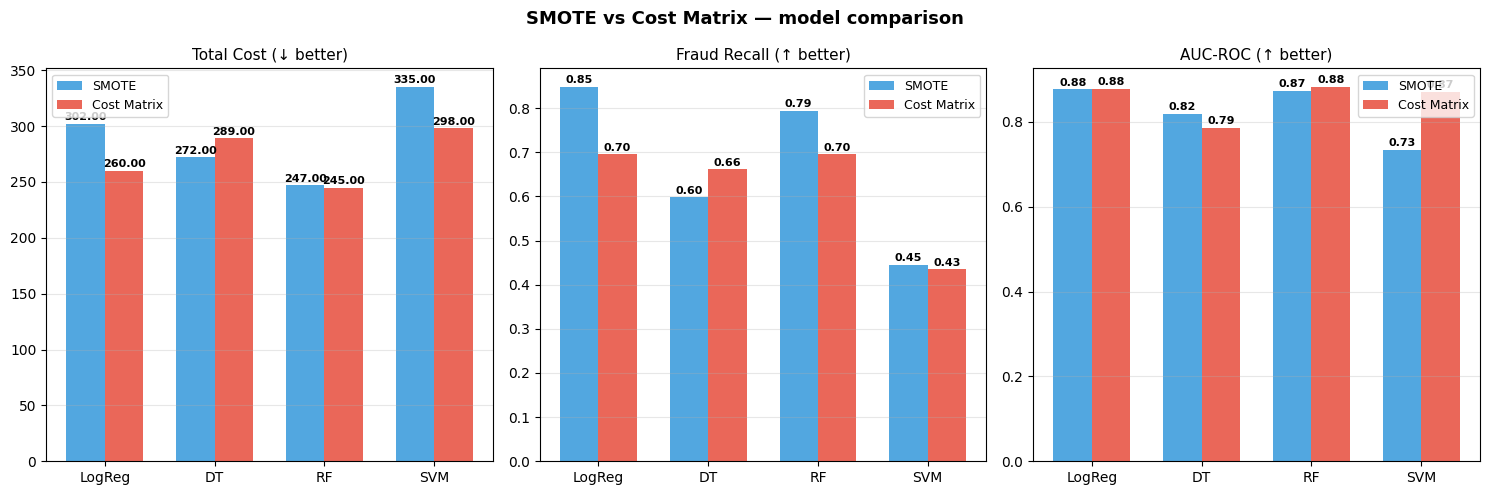

In [33]:
# =========================================================
# DIRECT COMPARISON: SMOTE vs COST MATRIX (+ SVM)
# =========================================================

results_smote = pd.DataFrame([
    evaluate_cost('LogReg SMOTE', y_test,
                  log_reg.predict_proba(X_test_13)[:, 1],
                  THRESHOLD, COST_FN, COST_FP),
    evaluate_cost('DT SMOTE',    y_test,
                  dt_best_model.predict_proba(X_test_13)[:, 1],
                  THRESHOLD, COST_FN, COST_FP),
    evaluate_cost('RF SMOTE',    y_test,
                  rf_best_model.predict_proba(X_test_13)[:, 1],
                  THRESHOLD, COST_FN, COST_FP),
    evaluate_cost('SVM SMOTE',   y_test,
                  svm_smote.predict_proba(X_test_13)[:, 1],
                  THRESHOLD, COST_FN, COST_FP),
])

comparison = pd.concat([results_smote, results_cost], ignore_index=True)
comparison['Approach'] = (['SMOTE'] * 4 + ['Cost Matrix'] * 4)

print("\n--- SMOTE vs COST MATRIX: TOTAL COST COMPARISON ---")
pivot = comparison[
    ['Model', 'Approach', 'Recall', 'AUC',
     'Cost_FN', 'Cost_FP', 'Total_Cost']
]
print(pivot.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ── Visualization comparison ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("SMOTE vs Cost Matrix — model comparison",
             fontsize=13, fontweight='bold')

models  = ['LogReg', 'DT', 'RF', 'SVM']
metrics = ['Total_Cost', 'Recall', 'AUC']
titles  = ['Total Cost (↓ better)', 'Fraud Recall (↑ better)', 'AUC-ROC (↑ better)']
colors  = {'SMOTE': '#3498db', 'Cost Matrix': '#e74c3c'}

for ax, metric, title in zip(axes, metrics, titles):
    x     = np.arange(len(models))
    width = 0.35

    for i, approach in enumerate(['SMOTE', 'Cost Matrix']):
        vals = comparison[comparison['Approach'] == approach][metric].values
        bars = ax.bar(x + (i - 0.5) * width, vals, width,
                      label=approach, color=colors[approach], alpha=0.85)

        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(vals) * 0.01,
                    f"{v:.2f}", ha='center', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

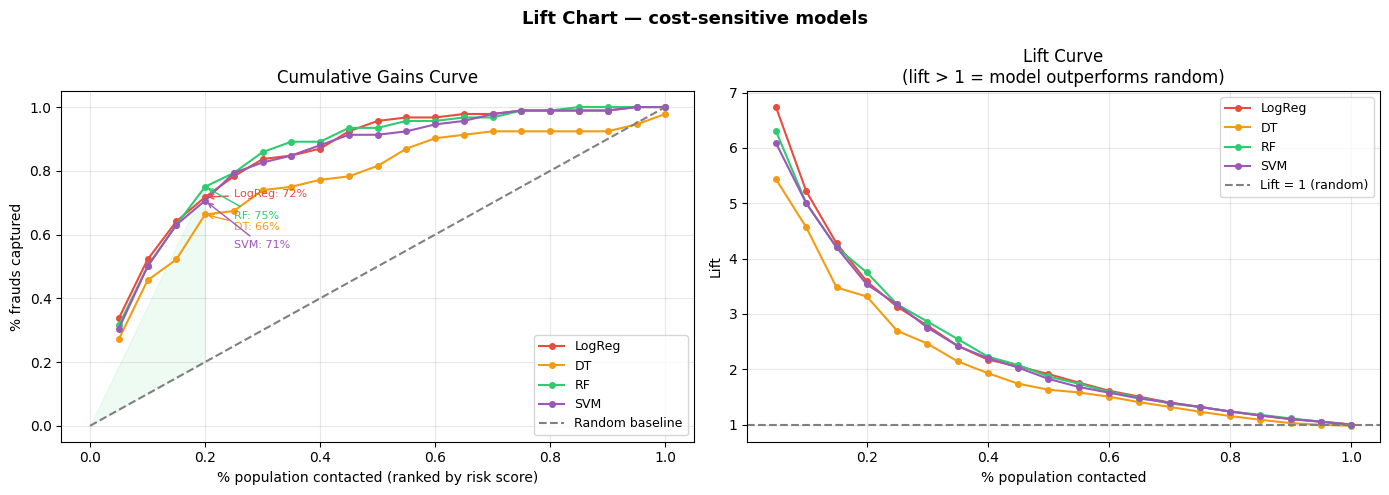


--- LIFT IN TOP 3 DECILES (top 10%, 20%, 30%) ---
  LogReg | top 10% → captures 52% of frauds (lift = 5.22x)
  LogReg | top 20% → captures 72% of frauds (lift = 3.59x)
  LogReg | top 30% → captures 84% of frauds (lift = 2.79x)

  DT | top 10% → captures 46% of frauds (lift = 4.57x)
  DT | top 20% → captures 66% of frauds (lift = 3.32x)
  DT | top 30% → captures 74% of frauds (lift = 2.46x)

  RF | top 10% → captures 50% of frauds (lift = 5.00x)
  RF | top 20% → captures 75% of frauds (lift = 3.75x)
  RF | top 30% → captures 86% of frauds (lift = 2.86x)

  SVM | top 10% → captures 50% of frauds (lift = 5.00x)
  SVM | top 20% → captures 71% of frauds (lift = 3.53x)
  SVM | top 30% → captures 83% of frauds (lift = 2.75x)



In [34]:
# =========================================================
# LIFT CHART — cost-sensitive models (+ SVM)
# =========================================================

def compute_lift(y_true, y_prob, n_bins=20):
    df_lift = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})
    df_lift = df_lift.sort_values('y_prob', ascending=False).reset_index(drop=True)

    total_fraud = y_true.sum()
    n           = len(y_true)
    bin_size    = n // n_bins
    rows        = []

    for i in range(n_bins):
        chunk           = df_lift.iloc[i * bin_size : (i + 1) * bin_size]
        cum_chunk       = df_lift.iloc[: (i + 1) * bin_size]
        pct_population  = (i + 1) / n_bins
        cum_fraud_caught = cum_chunk['y_true'].sum() / total_fraud
        lift            = cum_fraud_caught / pct_population

        rows.append({
            'pct_population':  pct_population,
            'cum_fraud_caught': cum_fraud_caught,
            'lift':            lift,
        })

    return pd.DataFrame(rows)


lift_data = {
    name: compute_lift(np.array(y_test), prob)
    for name, prob in probs.items()
}

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Lift Chart — cost-sensitive models",
             fontsize=13, fontweight='bold')

palette = {
    'LogReg': '#e74c3c',
    'DT':     '#f39c12',
    'RF':     '#2ecc71',
    'SVM':    '#9b59b6',   # viola per distinguerlo
}

# Panel 1: Cumulative Gains
ax = axes[0]

for name, df_l in lift_data.items():
    ax.plot(df_l['pct_population'], df_l['cum_fraud_caught'],
            marker='o', markersize=4, label=name, color=palette[name])

ax.plot([0, 1], [0, 1], '--', color='grey', label='Random baseline')

# shading top 20% area — riferimento RF
ax.fill_between(
    [0, 0.2], [0, 0.2],
    [0, lift_data['RF']['cum_fraud_caught'].iloc[3]],
    alpha=0.08, color='#2ecc71'
)

ax.set_xlabel("% population contacted (ranked by risk score)")
ax.set_ylabel("% frauds captured")
ax.set_title("Cumulative Gains Curve")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Annotazioni top 20% — offset verticali per evitare sovrapposizioni
offsets = {'LogReg': 0.00, 'DT': -0.05, 'RF': -0.10, 'SVM': -0.15}

for name, df_l in lift_data.items():
    val = df_l.loc[df_l['pct_population'] <= 0.21, 'cum_fraud_caught'].max()
    ax.annotate(
        f"{name}: {val:.0%}",
        xy=(0.20, val),
        fontsize=8,
        color=palette[name],
        xytext=(0.25, val + offsets[name]),
        arrowprops=dict(arrowstyle='->', color=palette[name], lw=1)
    )

# Panel 2: Lift curve
ax2 = axes[1]

for name, df_l in lift_data.items():
    ax2.plot(df_l['pct_population'], df_l['lift'],
             marker='o', markersize=4, label=name, color=palette[name])

ax2.axhline(1, linestyle='--', color='grey', label='Lift = 1 (random)')
ax2.set_xlabel("% population contacted")
ax2.set_ylabel("Lift")
ax2.set_title("Lift Curve\n(lift > 1 = model outperforms random)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Top deciles summary ───────────────────────────────────
print("\n--- LIFT IN TOP 3 DECILES (top 10%, 20%, 30%) ---")

for name, df_l in lift_data.items():
    for pct in [0.10, 0.20, 0.30]:
        row = df_l[df_l['pct_population'] <= pct + 0.01].iloc[-1]
        print(f"  {name} | top {pct:.0%} → captures "
              f"{row['cum_fraud_caught']:.0%} of frauds "
              f"(lift = {row['lift']:.2f}x)")
    print()

# CONFRONTO OVERSAMPLING vs COST SENSITIVE

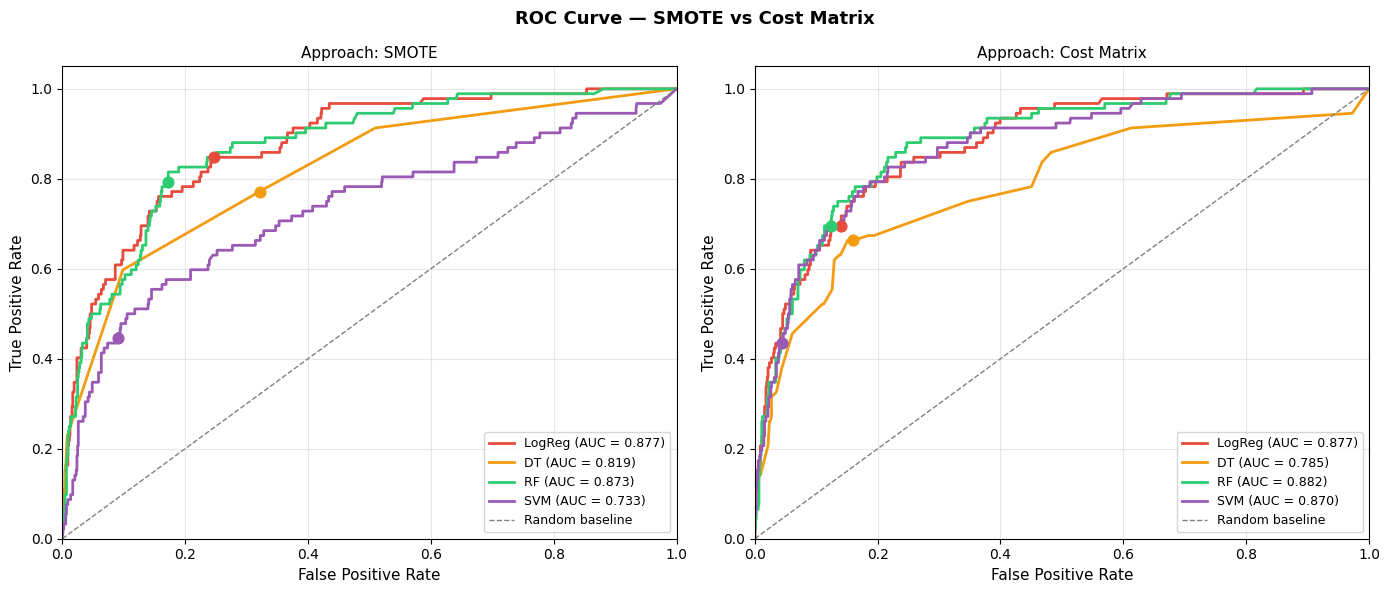

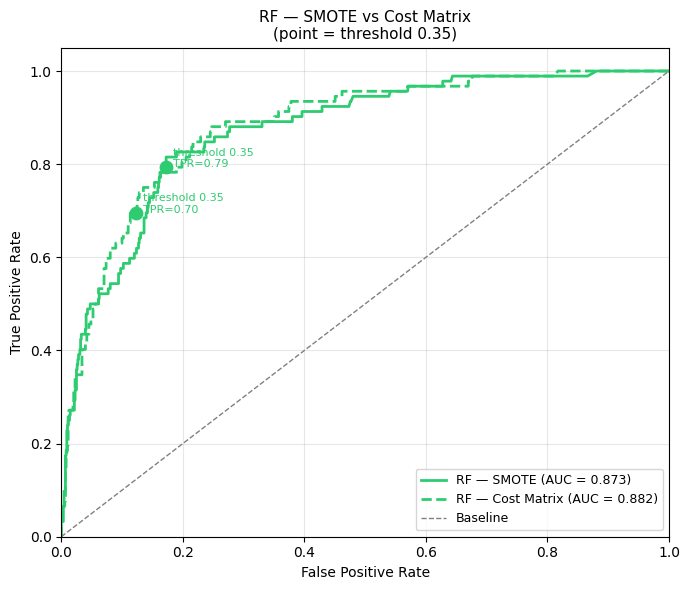

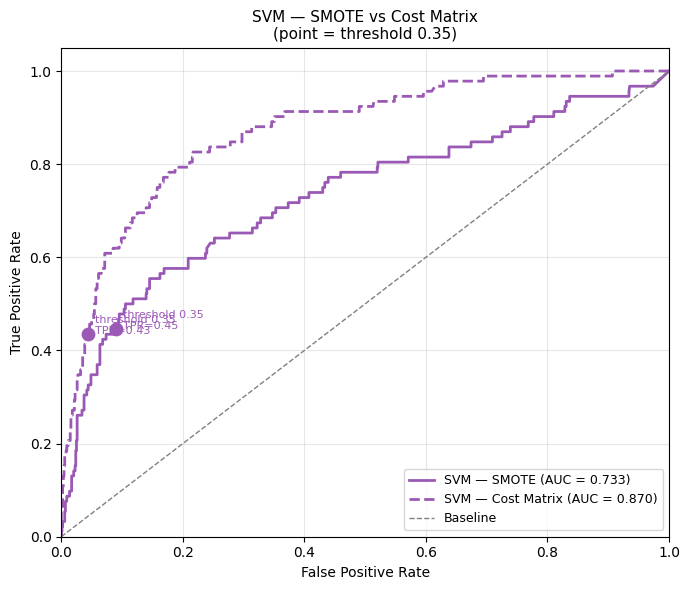

In [24]:
# =========================================================
# ROC CURVE — FULL MODEL COMPARISON (SMOTE vs COST MATRIX)
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ROC Curve — SMOTE vs Cost Matrix",
             fontsize=13, fontweight='bold')

# ── palette ──────────────────────────────────────────────
palette = {
    'LogReg': '#e74c3c',
    'DT':     '#f39c12',
    'RF':     '#2ecc71',
    'SVM':    '#9b59b6',
}

# ── SMOTE models ─────────────────────────────────────────
smote_models = {
    'LogReg': log_reg,
    'DT':     dt_best_model,
    'RF':     rf_best_model,
    'SVM':    svm_smote,
}

# ── Cost Matrix models ───────────────────────────────────
cost_models = {
    'LogReg': log_cost,
    'DT':     dt_cost,
    'RF':     rf_cost,
    'SVM':    svm_cost,
}

for ax, (models_dict, title) in zip(axes, [
    (smote_models, 'SMOTE'),
    (cost_models,  'Cost Matrix'),
]):
    for name, model in models_dict.items():
        y_prob          = model.predict_proba(X_test_13)[:, 1]
        fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)
        roc_auc         = auc(fpr, tpr)

        ax.plot(fpr, tpr, linewidth=2, color=palette[name],
                label=f'{name} (AUC = {roc_auc:.3f})')

        thresh_idx = np.argmin(np.abs(roc_thresh - THRESHOLD))
        ax.scatter(fpr[thresh_idx], tpr[thresh_idx],
                   color=palette[name], s=60, zorder=5)

    ax.plot([0, 1], [0, 1], '--', linewidth=1,
            color='grey', label='Random baseline')
    ax.set_xlim([0, 1]);  ax.set_ylim([0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(f"Approach: {title}", fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ── Single comparative ROC: RF SMOTE vs RF Cost Matrix ───

fig, ax = plt.subplots(figsize=(7, 6))

for label, model, ls in [
    ('RF — SMOTE',        rf_best_model, '-'),
    ('RF — Cost Matrix',  rf_cost,       '--'),
]:
    y_prob               = model.predict_proba(X_test_13)[:, 1]
    fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)
    roc_auc              = auc(fpr, tpr)

    ax.plot(fpr, tpr, linestyle=ls, linewidth=2, color='#2ecc71',
            label=f'{label} (AUC = {roc_auc:.3f})')

    thresh_idx = np.argmin(np.abs(roc_thresh - THRESHOLD))
    ax.scatter(fpr[thresh_idx], tpr[thresh_idx],
               color='#2ecc71', s=80, zorder=5)
    ax.annotate(
        f"  threshold {THRESHOLD}\n  TPR={tpr[thresh_idx]:.2f}",
        xy=(fpr[thresh_idx], tpr[thresh_idx]),
        fontsize=8, color='#2ecc71'
    )

ax.plot([0, 1], [0, 1], '--', linewidth=1, color='grey', label='Baseline')
ax.set_xlim([0, 1]);  ax.set_ylim([0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("RF — SMOTE vs Cost Matrix\n(point = threshold 0.35)", fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ── Single comparative ROC: SVM SMOTE vs SVM Cost Matrix ─
# (stesso confronto del blocco RF, applicato all'SVM)

fig, ax = plt.subplots(figsize=(7, 6))

for label, model, ls in [
    ('SVM — SMOTE',       svm_smote, '-'),
    ('SVM — Cost Matrix', svm_cost,  '--'),
]:
    y_prob               = model.predict_proba(X_test_13)[:, 1]
    fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)
    roc_auc              = auc(fpr, tpr)

    ax.plot(fpr, tpr, linestyle=ls, linewidth=2, color='#9b59b6',
            label=f'{label} (AUC = {roc_auc:.3f})')

    thresh_idx = np.argmin(np.abs(roc_thresh - THRESHOLD))
    ax.scatter(fpr[thresh_idx], tpr[thresh_idx],
               color='#9b59b6', s=80, zorder=5)
    ax.annotate(
        f"  threshold {THRESHOLD}\n  TPR={tpr[thresh_idx]:.2f}",
        xy=(fpr[thresh_idx], tpr[thresh_idx]),
        fontsize=8, color='#9b59b6'
    )

ax.plot([0, 1], [0, 1], '--', linewidth=1, color='grey', label='Baseline')
ax.set_xlim([0, 1]);  ax.set_ylim([0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("SVM — SMOTE vs Cost Matrix\n(point = threshold 0.35)", fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ALTRI GRAFICI 

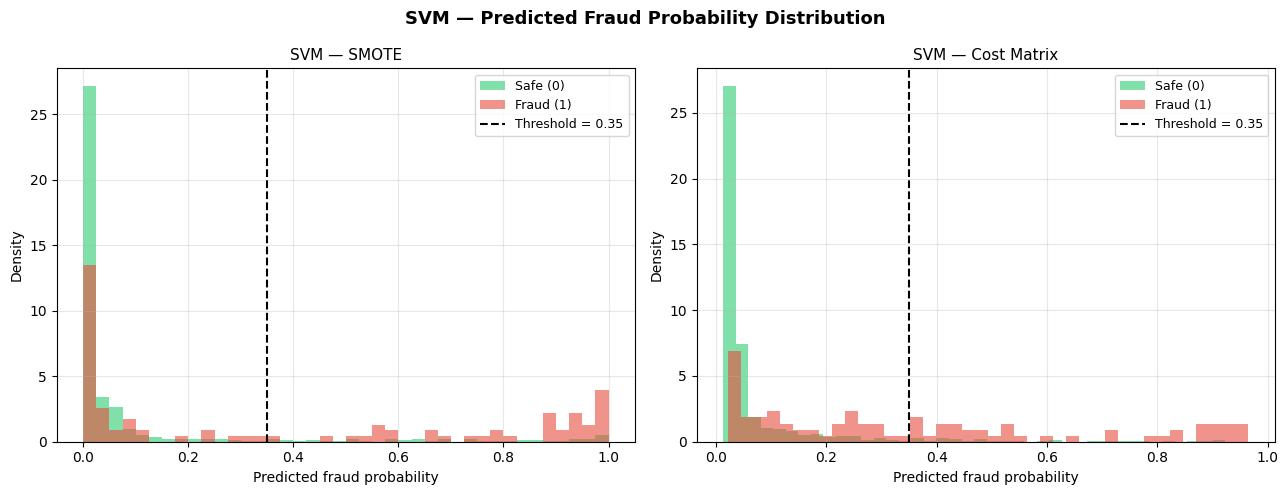

In [36]:
# =========================================================
# SVM — SCORE DISTRIBUTION: Safe vs Fraud
# Mostra quanto bene il modello separa le probabilità
# delle due classi — più le distribuzioni sono separate,
# migliore è il modello
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("SVM — Predicted Fraud Probability Distribution",
             fontsize=13, fontweight='bold')

for ax, (y_prob, title) in zip(axes, [
    (svm_smote.predict_proba(X_test_13)[:, 1], 'SMOTE'),
    (probs['SVM'],                               'Cost Matrix'),
]):
    y_test_arr = np.array(y_test)

    ax.hist(y_prob[y_test_arr == 0], bins=40, alpha=0.6,
            color='#2ecc71', label='Safe (0)', density=True)
    ax.hist(y_prob[y_test_arr == 1], bins=40, alpha=0.6,
            color='#e74c3c', label='Fraud (1)', density=True)
    ax.axvline(THRESHOLD, linestyle='--', color='black',
               linewidth=1.5, label=f'Threshold = {THRESHOLD}')

    ax.set_xlabel("Predicted fraud probability")
    ax.set_ylabel("Density")
    ax.set_title(f"SVM — {title}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

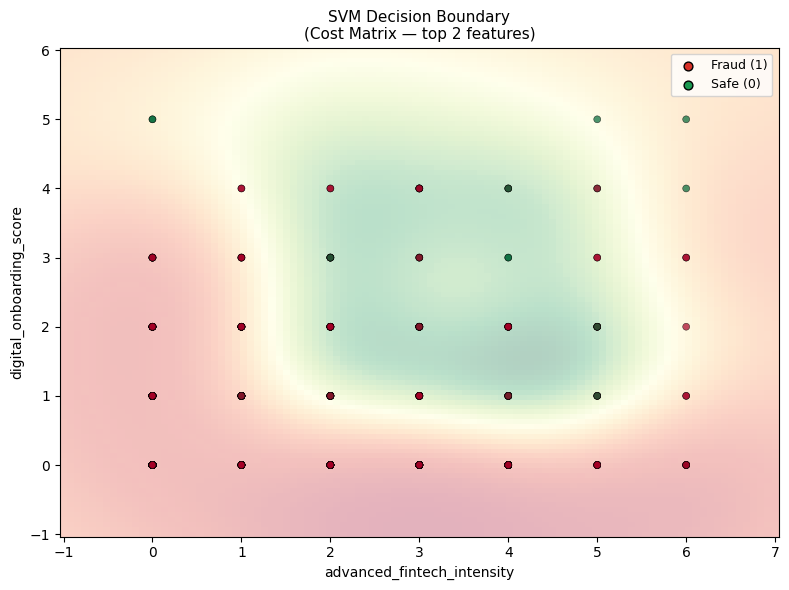

In [37]:
# =========================================================
# SVM — DECISION BOUNDARY (top 2 features)
# Utile per mostrare come l'SVM separa le classi
# nello spazio delle variabili più predittive
# =========================================================
from sklearn.inspection import DecisionBoundaryDisplay

# top 2 feature per correlazione con il target
top2 = ['advanced_fintech_intensity', 'digital_onboarding_score']

X_train_2d = X_train_13[top2].values
X_test_2d  = X_test_13[top2].values

svm_2d = SVC(
    C=          grid_svm_cost.best_params_['C'],
    gamma=      grid_svm_cost.best_params_['gamma'],
    kernel=     grid_svm_cost.best_params_['kernel'],
    class_weight=cost_weights,
    probability=True,
    random_state=42
)
svm_2d.fit(X_train_2d, y_train)

fig, ax = plt.subplots(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    svm_2d, X_test_2d,
    response_method='predict_proba',
    plot_method='pcolormesh',
    alpha=0.3, ax=ax, cmap='RdYlGn'
)

scatter = ax.scatter(
    X_test_2d[:, 0], X_test_2d[:, 1],
    c=np.array(y_test), cmap='RdYlGn',
    edgecolors='k', linewidths=0.4, s=25, alpha=0.7
)

ax.set_xlabel("advanced_fintech_intensity")
ax.set_ylabel("digital_onboarding_score")
ax.set_title("SVM Decision Boundary\n(Cost Matrix — top 2 features)",
             fontsize=11)

legend_elements = [
    plt.scatter([], [], c='#d73027', edgecolors='k', s=40, label='Fraud (1)'),
    plt.scatter([], [], c='#1a9850', edgecolors='k', s=40, label='Safe (0)'),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

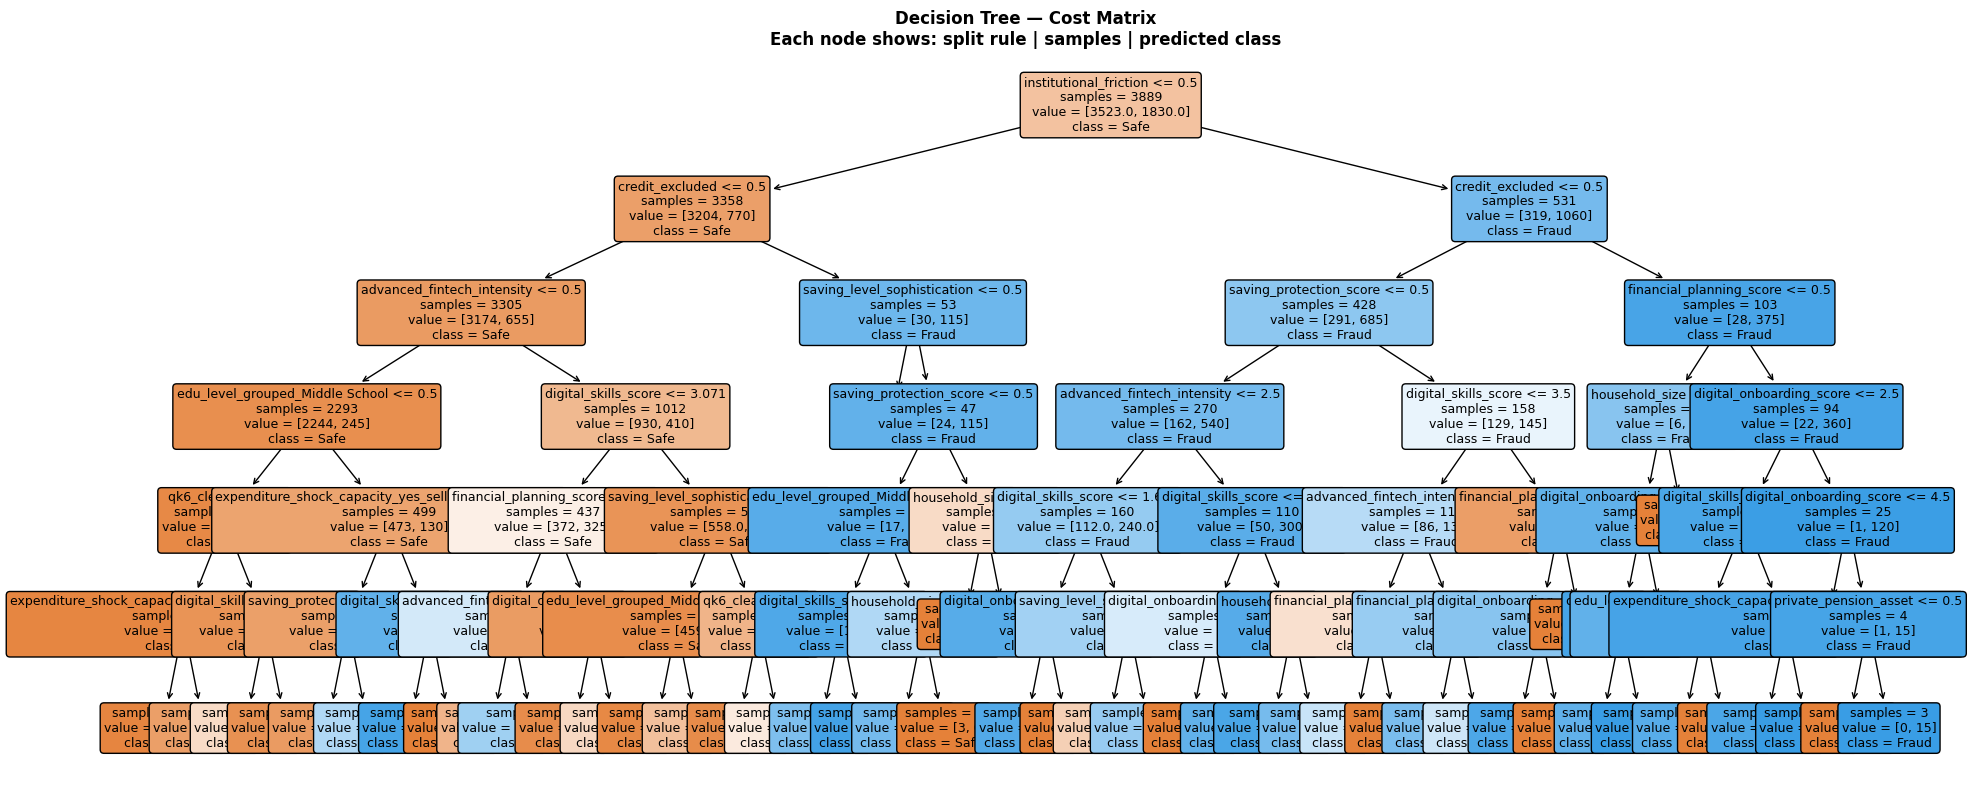

In [38]:
# =========================================================
# DECISION TREE — Tree Visualization
# La visualizzazione più pitchabile del DT:
# ogni nodo è una regola di business leggibile
# =========================================================
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    dt_cost,
    feature_names=core_features,
    class_names=['Safe', 'Fraud'],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,      # nasconde gini/entropy — più pulito per pitch
    proportion=False,
    ax=ax
)

ax.set_title(
    "Decision Tree — Cost Matrix\n"
    "Each node shows: split rule | samples | predicted class",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

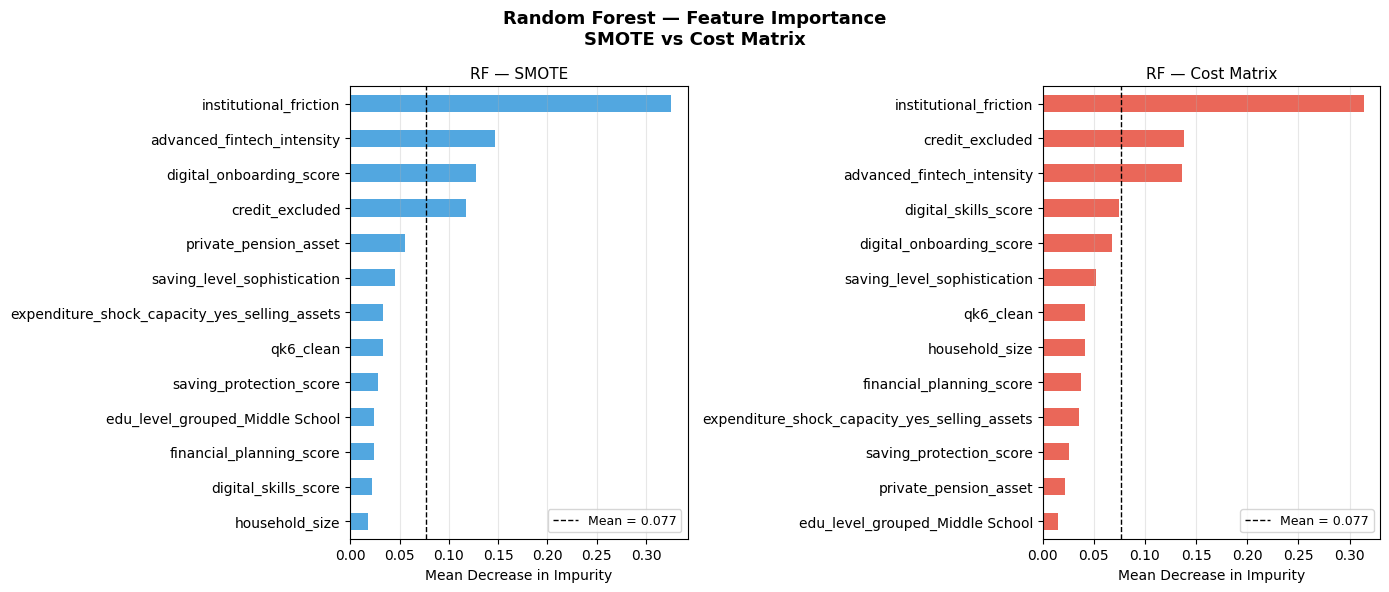

In [39]:
# =========================================================
# RANDOM FOREST — Feature Importance (MDI)
# Confronto SMOTE vs Cost Matrix:
# le importanze cambiano quando si cambia strategia?
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Random Forest — Feature Importance\nSMOTE vs Cost Matrix",
             fontsize=13, fontweight='bold')

for ax, (model, title, color) in zip(axes, [
    (rf_best_model, 'SMOTE',       '#3498db'),
    (rf_cost,       'Cost Matrix',  '#e74c3c'),
]):
    importances = pd.Series(
        model.feature_importances_,
        index=core_features
    ).sort_values(ascending=True)

    importances.plot(kind='barh', ax=ax, color=color, alpha=0.85)

    ax.set_title(f"RF — {title}", fontsize=11)
    ax.set_xlabel("Mean Decrease in Impurity")
    ax.axvline(importances.mean(), linestyle='--',
               color='black', linewidth=1,
               label=f'Mean = {importances.mean():.3f}')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

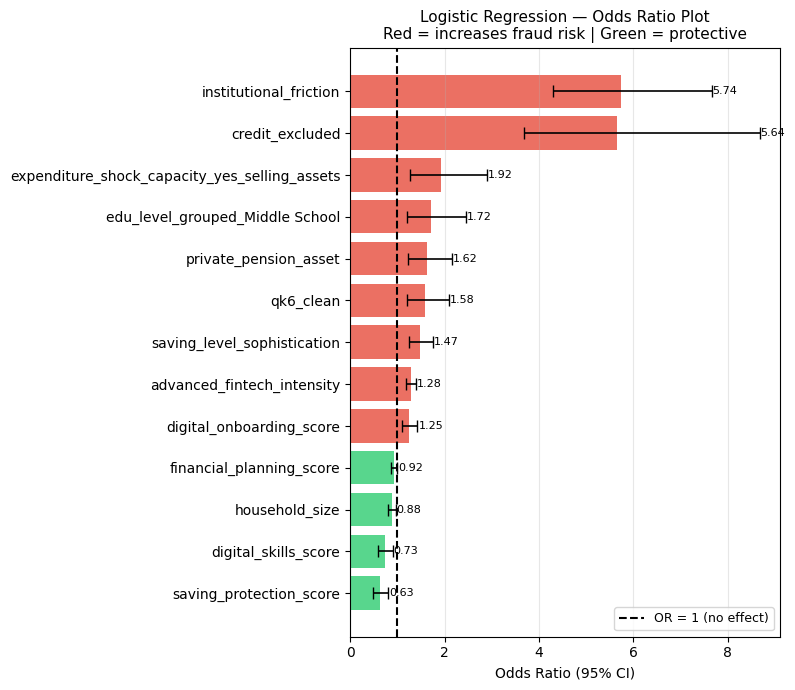

In [40]:
# =========================================================
# LOGISTIC REGRESSION — Odds Ratio Plot
# Visualizzazione dei coefficienti con intervalli
# di confidenza al 95% — standard accademico e aziendale
# =========================================================
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_13)
result      = sm.Logit(y_train, X_train_sm).fit(disp=False)

# odds ratio e IC 95%
or_df = pd.DataFrame({
    'feature': core_features,
    'OR':      np.exp(result.params[1:].values),
    'CI_low':  np.exp(result.conf_int().iloc[1:, 0].values),
    'CI_high': np.exp(result.conf_int().iloc[1:, 1].values),
    'p_value': result.pvalues[1:].values,
}).sort_values('OR', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#e74c3c' if or_val > 1 else '#2ecc71'
          for or_val in or_df['OR']]

ax.barh(or_df['feature'], or_df['OR'],
        xerr=[or_df['OR'] - or_df['CI_low'],
              or_df['CI_high'] - or_df['OR']],
        color=colors, alpha=0.8, capsize=4,
        error_kw={'linewidth': 1.2})

ax.axvline(1, linestyle='--', color='black',
           linewidth=1.5, label='OR = 1 (no effect)')

# etichetta OR su ogni barra
for _, row in or_df.iterrows():
    ax.text(row['CI_high'] + 0.02, row['feature'],
            f"{row['OR']:.2f}", va='center', fontsize=8)

ax.set_xlabel("Odds Ratio (95% CI)")
ax.set_title("Logistic Regression — Odds Ratio Plot\n"
             "Red = increases fraud risk | Green = protective",
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# XAI SU SVM e RANDOM FOREST

### XAI Random Forest con SMOTE

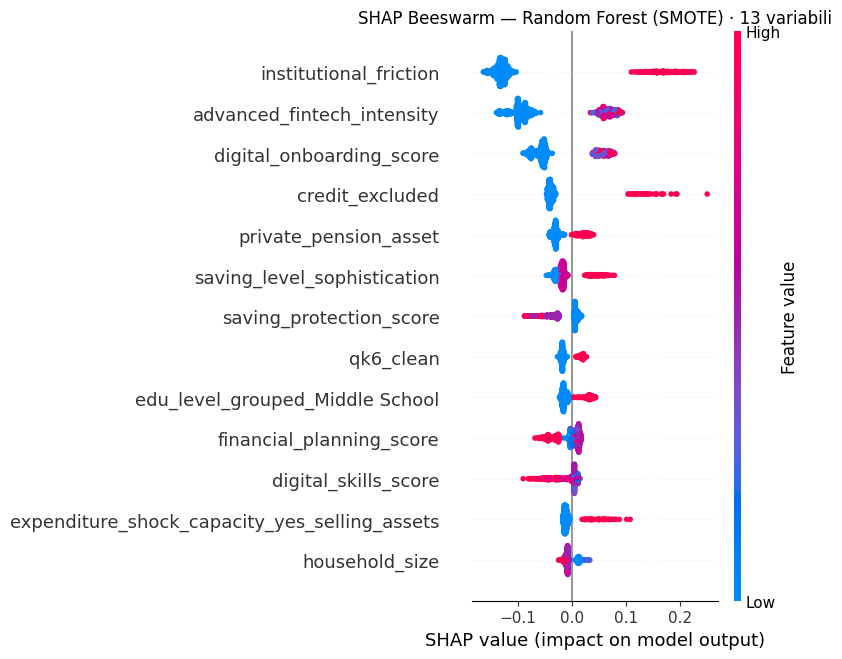

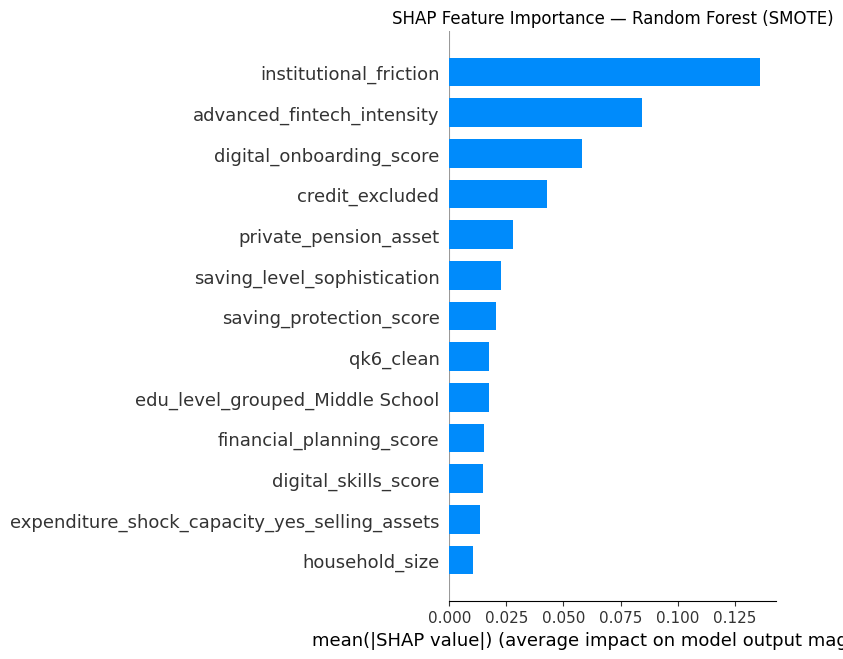

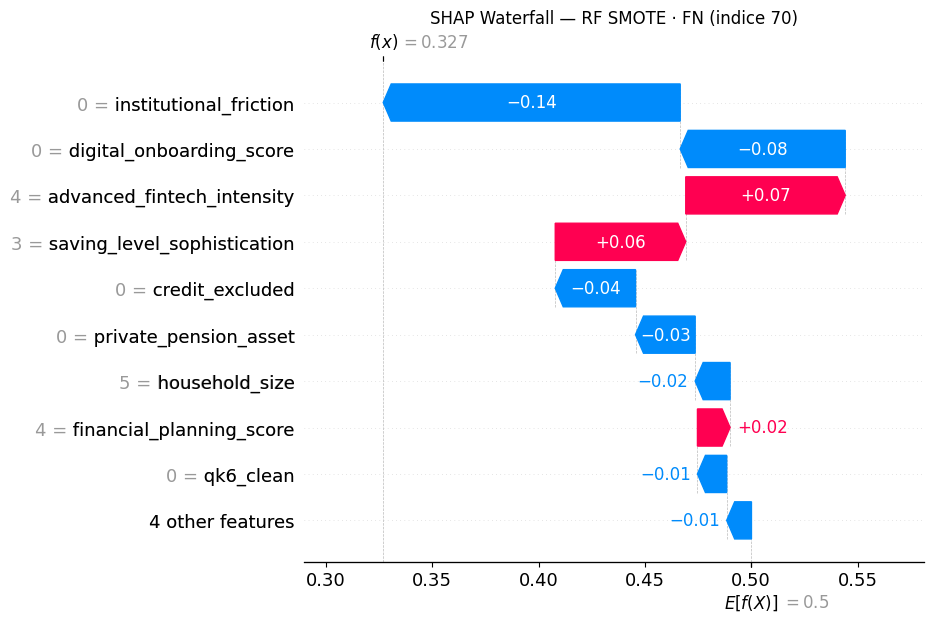

In [ ]:
# =========================================================
# XAI — SHAP TreeExplainer · Random Forest (SMOTE)
# =========================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

explainer_rf_smote   = shap.TreeExplainer(rf_best_model)
shap_values_rf_smote = explainer_rf_smote.shap_values(X_test_13)

# Gestisce sia formato lista [cl0, cl1] che array 3D (n, f, 2)
if isinstance(shap_values_rf_smote, list):
    sv_rf_smote = shap_values_rf_smote[1]
    bv_rf_smote = explainer_rf_smote.expected_value[1]
else:
    sv_rf_smote = shap_values_rf_smote[:, :, 1]
    bv_rf_smote = explainer_rf_smote.expected_value[1]

# ── Beeswarm ──────────────────────────────────────────────
plt.figure()
plt.title("SHAP Beeswarm — Random Forest (SMOTE) · 13 variabili")
shap.summary_plot(
    sv_rf_smote,
    X_test_13,
    plot_type="dot",
    max_display=13,
    show=True
)

# ── Bar plot ──────────────────────────────────────────────
plt.figure()
plt.title("SHAP Feature Importance — Random Forest (SMOTE)")
shap.summary_plot(
    sv_rf_smote,
    X_test_13,
    plot_type="bar",
    max_display=13,
    show=True
)

# ── Waterfall su un Falso Negativo ────────────────────────
y_test_arr      = np.array(y_test)
y_pred_rf_smote = (
    rf_best_model.predict_proba(X_test_13)[:, 1] >= 0.35
).astype(int)

fn_indices = np.where(
    (y_test_arr == 1) & (y_pred_rf_smote == 0)
)[0]

if len(fn_indices) > 0:
    idx = fn_indices[0]

    shap_exp = shap.Explanation(
        values        = sv_rf_smote[idx],
        base_values   = bv_rf_smote,
        data          = X_test_13.iloc[idx].values,
        feature_names = X_test_13.columns.tolist()
    )

    plt.figure()
    plt.title(f"SHAP Waterfall — RF SMOTE · FN (indice {idx})")
    shap.plots.waterfall(shap_exp, show=True)

### XAI su Random Forest con COST SENSITIVE

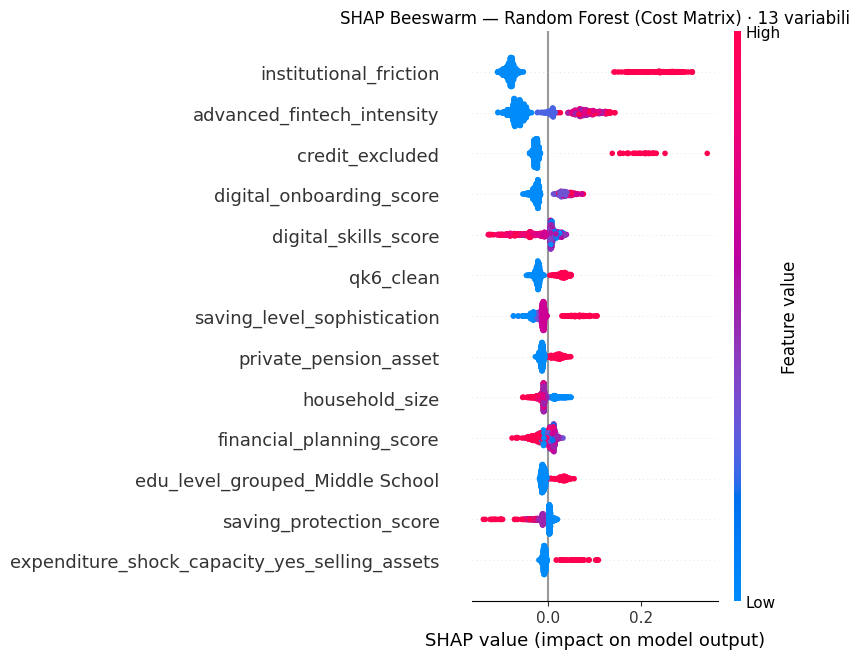

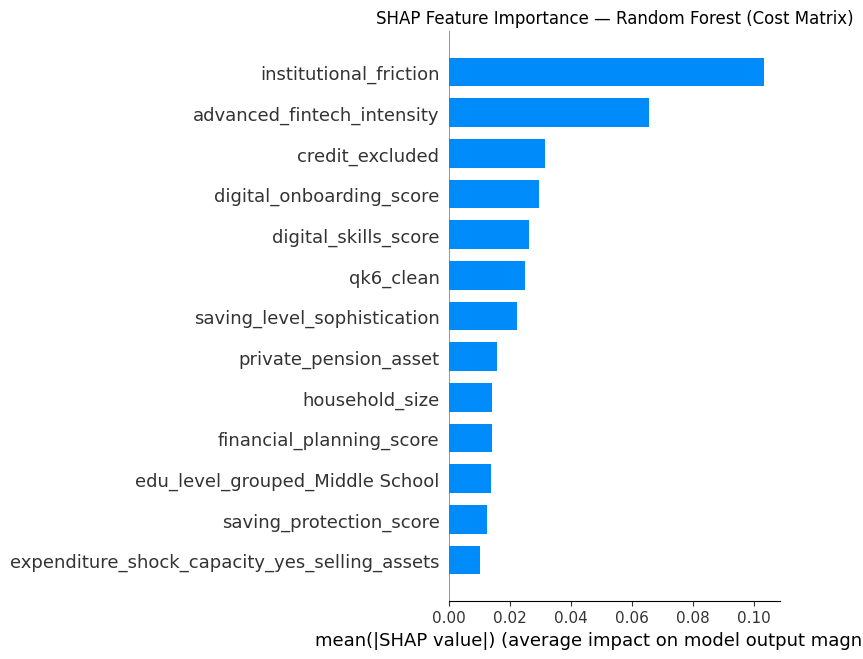

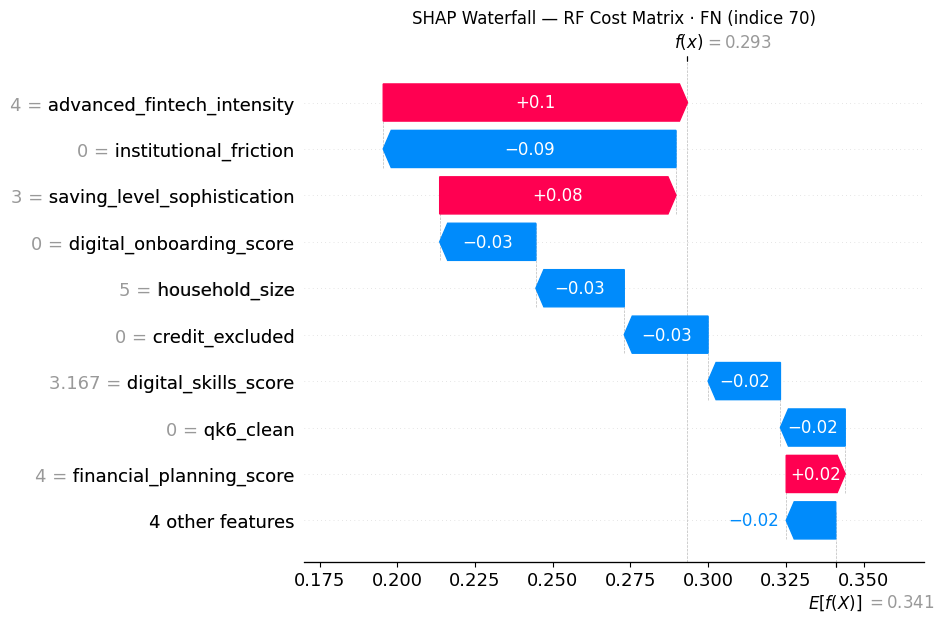

In [27]:
# =========================================================
# XAI — SHAP TreeExplainer · Random Forest (Cost Matrix)
# =========================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

explainer_rf_cost   = shap.TreeExplainer(rf_cost)
shap_values_rf_cost = explainer_rf_cost.shap_values(X_test_13)

# Gestisce sia formato lista [cl0, cl1] che array 3D (n, f, 2)
if isinstance(shap_values_rf_cost, list):
    sv_rf_cost = shap_values_rf_cost[1]
    bv_rf_cost = explainer_rf_cost.expected_value[1]
else:
    sv_rf_cost = shap_values_rf_cost[:, :, 1]
    bv_rf_cost = explainer_rf_cost.expected_value[1]

# ── Beeswarm ──────────────────────────────────────────────
plt.figure()
plt.title("SHAP Beeswarm — Random Forest (Cost Matrix) · 13 variabili")
shap.summary_plot(
    sv_rf_cost,
    X_test_13,
    plot_type="dot",
    max_display=13,
    show=True
)

# ── Bar plot ──────────────────────────────────────────────
plt.figure()
plt.title("SHAP Feature Importance — Random Forest (Cost Matrix)")
shap.summary_plot(
    sv_rf_cost,
    X_test_13,
    plot_type="bar",
    max_display=13,
    show=True
)

# ── Waterfall su un Falso Negativo ────────────────────────
y_test_arr     = np.array(y_test)
y_pred_rf_cost = (
    rf_cost.predict_proba(X_test_13)[:, 1] >= 0.35
).astype(int)

fn_indices = np.where(
    (y_test_arr == 1) & (y_pred_rf_cost == 0)
)[0]

if len(fn_indices) > 0:
    idx = fn_indices[0]

    shap_exp = shap.Explanation(
        values        = sv_rf_cost[idx],
        base_values   = bv_rf_cost,
        data          = X_test_13.iloc[idx].values,
        feature_names = X_test_13.columns.tolist()
    )

    plt.figure()
    plt.title(f"SHAP Waterfall — RF Cost Matrix · FN (indice {idx})")
    shap.plots.waterfall(shap_exp, show=True)

### XAI su SVM smote

  0%|          | 0/30 [00:00<?, ?it/s]

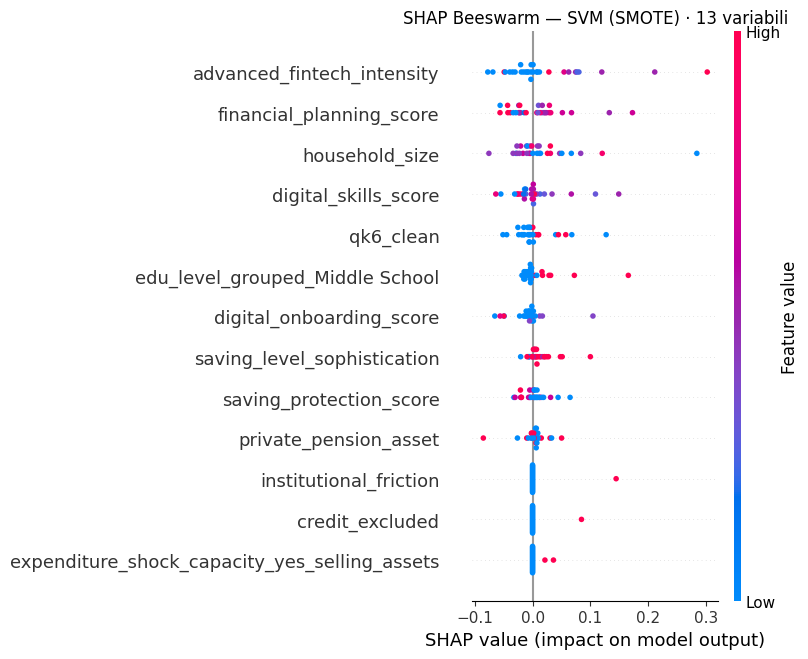

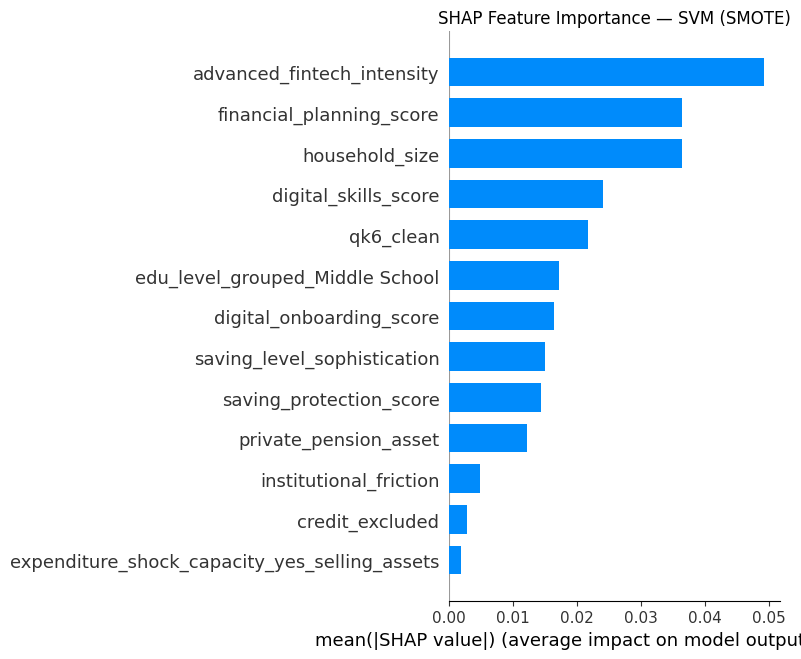

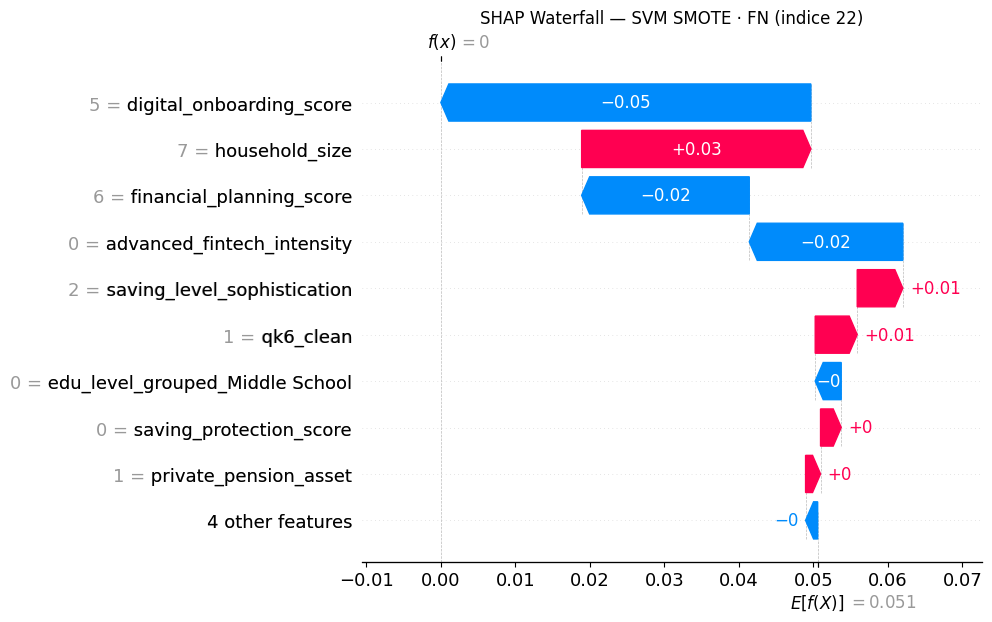

In [32]:
# =========================================================
# XAI — SHAP KernelExplainer · SVM (SMOTE)
# kernel rbf — background 10 punti, test 30 righe
# tempo atteso: ~55 secondi
# =========================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

# reset dell'indice PRIMA di campionare
X_test_13_reset = X_test_13.reset_index(drop=True)
y_test_arr      = np.array(y_test)  # già allineato 0..972

X_bg_smote    = shap.sample(X_train_13, 10, random_state=42)
X_test_shap_s = X_test_13_reset.sample(30, random_state=42)
y_test_shap_s = y_test_arr[X_test_shap_s.index]  # ora funziona
X_test_shap_s = X_test_shap_s.reset_index(drop=True)

explainer_svm_smote = shap.KernelExplainer(
    lambda x: svm_smote.predict_proba(x)[:, 1],
    X_bg_smote
)

shap_values_svm_smote = explainer_svm_smote.shap_values(
    X_test_shap_s, silent=False
)

# ── Beeswarm ──────────────────────────────────────────────
plt.figure()
plt.title("SHAP Beeswarm — SVM (SMOTE) · 13 variabili")
shap.summary_plot(
    shap_values_svm_smote,
    X_test_shap_s,
    plot_type="dot",
    max_display=13,
    show=True
)

# ── Bar plot ──────────────────────────────────────────────
plt.figure()
plt.title("SHAP Feature Importance — SVM (SMOTE)")
shap.summary_plot(
    shap_values_svm_smote,
    X_test_shap_s,
    plot_type="bar",
    max_display=13,
    show=True
)

# ── Waterfall su un Falso Negativo ────────────────────────
y_pred_shap_s = (
    svm_smote.predict_proba(X_test_shap_s)[:, 1] >= 0.35
).astype(int)

fn_indices = np.where(
    (y_test_shap_s == 1) & (y_pred_shap_s == 0)
)[0]

if len(fn_indices) > 0:
    idx = fn_indices[0]
    shap_exp = shap.Explanation(
        values        = shap_values_svm_smote[idx],
        base_values   = explainer_svm_smote.expected_value,
        data          = X_test_shap_s.iloc[idx].values,
        feature_names = X_test_13.columns.tolist()
    )
    plt.figure()
    plt.title(f"SHAP Waterfall — SVM SMOTE · FN (indice {idx})")
    shap.plots.waterfall(shap_exp, show=True)
else:
    print("Nessun FN nelle 30 righe — prova random_state=1 o aumenta il sample.")

### XAI su SVM con COST SENSITIVE

  0%|          | 0/30 [00:00<?, ?it/s]

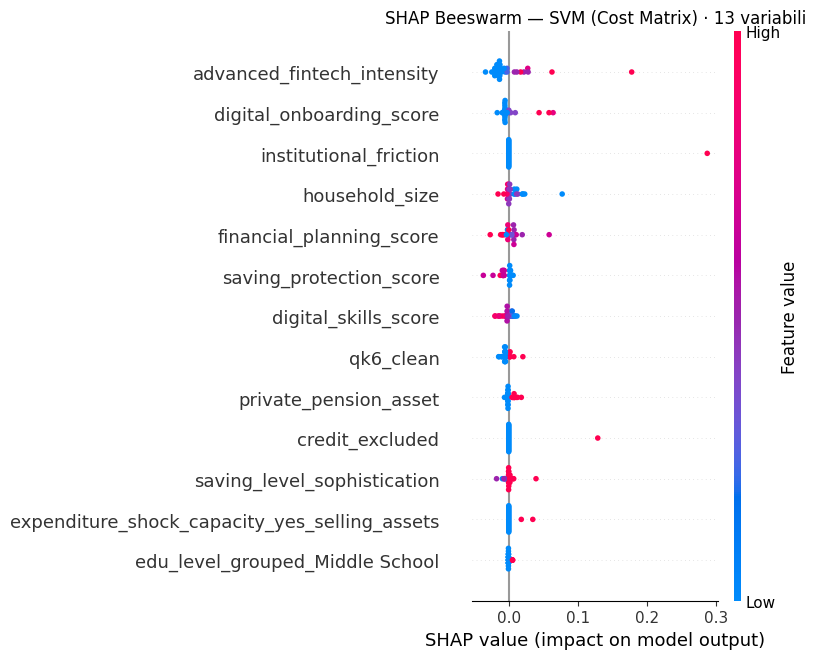

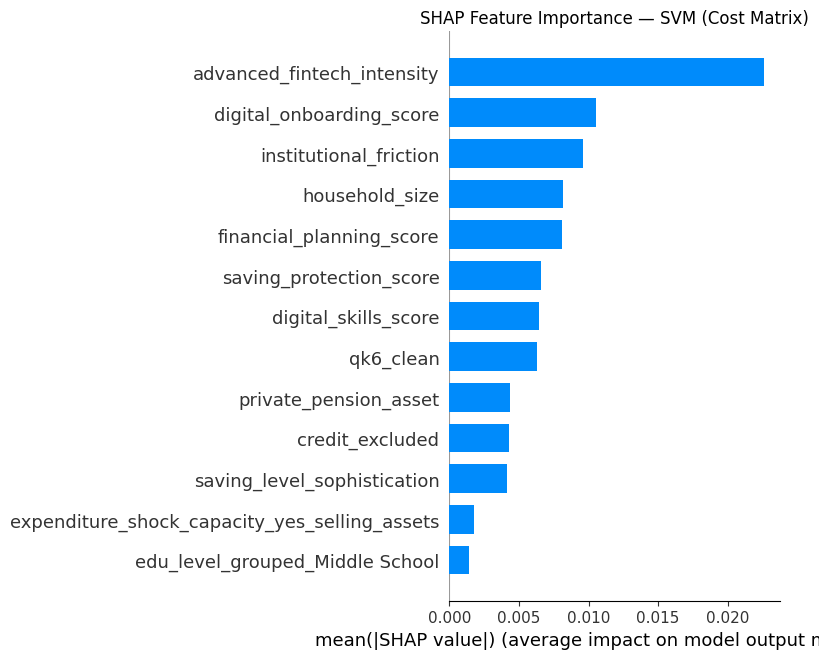

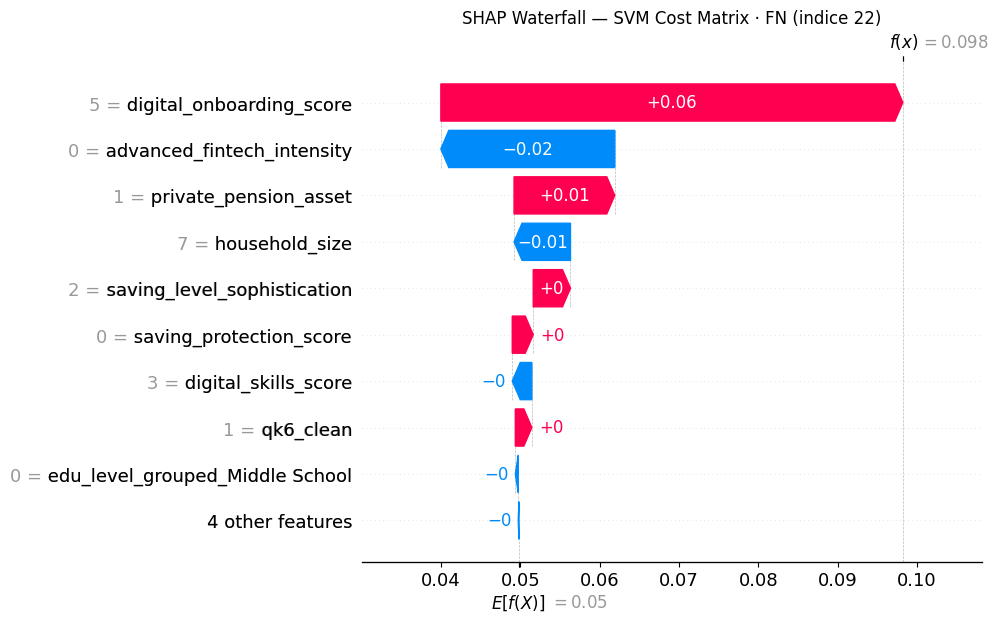

In [34]:
# =========================================================
# XAI — SHAP KernelExplainer · SVM (Cost Matrix)
# kernel rbf — background 10 punti, test 30 righe
# tempo atteso: ~55 secondi
# =========================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

# Fix indici — reset PRIMA di campionare
X_test_13_reset = X_test_13.reset_index(drop=True)
y_test_arr      = np.array(y_test)

X_bg_cost     = shap.sample(X_train_13, 10, random_state=42)
X_test_shap_c = X_test_13_reset.sample(30, random_state=42)
y_test_shap_c = y_test_arr[X_test_shap_c.index]
X_test_shap_c = X_test_shap_c.reset_index(drop=True)
explainer_svm_cost = shap.KernelExplainer(
    lambda x: svm_cost.predict_proba(x)[:, 1],
    X_bg_cost
)

shap_values_svm_cost = explainer_svm_cost.shap_values(
    X_test_shap_c, silent=False
)

# ── Beeswarm ──────────────────────────────────────────────
plt.figure()
plt.title("SHAP Beeswarm — SVM (Cost Matrix) · 13 variabili")
shap.summary_plot(
    shap_values_svm_cost,
    X_test_shap_c,
    plot_type="dot",
    max_display=13,
    show=True
)

# ── Bar plot ──────────────────────────────────────────────
plt.figure()
plt.title("SHAP Feature Importance — SVM (Cost Matrix)")
shap.summary_plot(
    shap_values_svm_cost,
    X_test_shap_c,
    plot_type="bar",
    max_display=13,
    show=True
)

# ── Waterfall su un Falso Negativo ────────────────────────
y_pred_shap_c = (
    svm_cost.predict_proba(X_test_shap_c)[:, 1] >= 0.35
).astype(int)

fn_indices = np.where(
    (y_test_shap_c == 1) & (y_pred_shap_c == 0)
)[0]

if len(fn_indices) > 0:
    idx = fn_indices[0]
    shap_exp = shap.Explanation(
        values        = shap_values_svm_cost[idx],
        base_values   = explainer_svm_cost.expected_value,
        data          = X_test_shap_c.iloc[idx].values,
        feature_names = X_test_13.columns.tolist()
    )
    plt.figure()
    plt.title(f"SHAP Waterfall — SVM Cost Matrix · FN (indice {idx})")
    shap.plots.waterfall(shap_exp, show=True)
else:
    print("Nessun FN nelle 30 righe — prova random_state=1 o aumenta il sample.")